In [1]:
# ── Cell 1 — imports, path & reload ───────────────────────────────────────────
import sys, os, importlib, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../.'))

import numpy as np
import matplotlib.pyplot as plt
import xso
from xso.parscans import run_xso_parscan, avg_tail

import cariaco_obs as co
import cariaco_npzd_setups as cns          # NPZD model (replaces cariaco_baseline_setups)
import parscan_utils as pu
import parscan_plots as pp
for m in (co, cns, pu, pp):                # pick up edits without a kernel restart
    importlib.reload(m)

phyto_esd, zoo_esd = cns.phyto_esd, cns.zoo_esd
print(f'grid: {len(phyto_esd)} phyto ({phyto_esd[0]:.2g}–{phyto_esd[-1]:.0f} µm), '
      f'{len(zoo_esd)} zoo ({zoo_esd[0]:.2g}–{zoo_esd[-1]:.0f} µm)')
print(f'spec: K_sZ={cns.K_SZ}  σ={cns.SIGMA}  GGE={cns.GGE_VAL}  '
      f'm_Z={cns.M_Z}  m_Zlin={cns.M_ZLIN}  θ_opt={cns.THETA_OPT}  '
      f'fish_rate(default)={cns.FISH_RATE}')

grid: 40 phyto (0.2–200 µm), 40 zoo (2–2000 µm)
spec: K_sZ=0.23  σ=0.15  GGE=0.25  m_Z=0.1  m_Zlin=0.05  θ_opt=10.0  fish_rate(default)=0.0


In [2]:
# ---- Cell 0 — Layered notebook: setup, baseline overrides, and helpers ------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import importlib

import cariaco_npzd_setups as ns
import cariaco_obs as co
import parscan_utils as pu
from xso.parscans import run_xso_parscan

importlib.reload(ns); importlib.reload(co); importlib.reload(pu)

# Upwelling-regime forcing
*_, mdf, forcing = co.load_cariaco_targets('upwelling', months='hplc',
                                           agg='median', include_temperature=True)
T_box = float(forcing['Temperature__value'])
n_P, n_Z = ns.phyto_esd.size, ns.zoo_esd.size

FN_VALUES = np.linspace(0.5, 12.0, 30)

# Baseline overrides applied to every layer: forcing + uniform 0.02 phyto mortality.
# Each layer adds its own structural change on top of this.
BASE_OVERRIDES = {k: v for k, v in forcing.items() if k != 'Inflow__FN'}
BASE_OVERRIDES['PhytoMortality__rate'] = np.full(n_P, 0.02)

# Sieburth band masks + axis formatter
m_pico  = ns.phyto_esd < 2.0
m_nano  = (ns.phyto_esd >= 2.0) & (ns.phyto_esd < 20.0)
m_micro = ns.phyto_esd >= 20.0
fmt = FuncFormatter(lambda x, _: f'{10**x:.0f}')


def run_layer(label, extra_overrides):
    """Run F_N parscan with BASE + extra overrides; return per-band biomass, mcs, N."""
    overrides = {**BASE_OVERRIDES, **extra_overrides}
    scan = run_xso_parscan(
        model_file_name='cariaco_npzd_setups',
        model_name='model_npzd',
        model_setup_name='model_setup_npzd_tani_scan',
        param_name='Inflow__FN',
        param_values=FN_VALUES,
        fixed_overrides=overrides,
        postprocess_name='avg_tail',
        postprocess_kwargs={'avg_window': 1000},
        processes=8,
    )
    order = np.argsort(scan['Inflow__FN'].values)
    FN  = scan['Inflow__FN'].values[order]
    P   = scan['Phytoplankton__biomass'].squeeze('time').values[order]
    Z   = scan['Zooplankton__biomass'].squeeze('time').values[order]
    N   = scan['Nutrient__value'].squeeze('time').values[order]
    log_esd = np.log10(ns.phyto_esd)
    mcs = (P * log_esd[None, :]).sum(axis=1) / np.maximum(P.sum(axis=1), 1e-30)
    pk  = int(np.argmax(mcs))
    return dict(
        label=label, FN=FN, P=P, Z=Z, N=N, mcs=mcs,
        peak_idx=pk, peak_FN=FN[pk],
        P_pico=P[:, m_pico].sum(axis=1),
        P_nano=P[:, m_nano].sum(axis=1),
        P_micro=P[:, m_micro].sum(axis=1),
    )


def plot_layer(current, previous=None):
    """Three-panel comparison: heatmap (current) + per-band overlay + mcs overlay."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

    # Panel 1: per-class P heatmap (current)
    im = axes[0].pcolormesh(current['FN'], np.log10(ns.phyto_esd), current['P'].T,
                            cmap='viridis', shading='nearest')
    axes[0].axvline(current['peak_FN'], color='w', lw=0.8, ls='--',
                    label=f"peak F_N≈{current['peak_FN']:.2f}")
    for esd_b in (2.0, 20.0):
        axes[0].axhline(np.log10(esd_b), color='w', lw=0.4, ls=':')
    axes[0].yaxis.set_major_formatter(fmt)
    axes[0].set_xlabel('F_N (mmol N m⁻³ d⁻¹)')
    axes[0].set_ylabel('phyto ESD (µm)')
    axes[0].set_title(f"P_k(F_N) — {current['label']}")
    axes[0].legend(loc='upper right', fontsize=8)
    fig.colorbar(im, ax=axes[0], label='P_k (mmol N m⁻³)')

    # Panel 2: per-band overlay (current solid, previous dashed)
    for lbl, key, col in [('Pico', 'P_pico', '#80b1d3'),
                          ('Nano', 'P_nano', '#fdb462'),
                          ('Micro', 'P_micro', '#bc3754')]:
        if previous is not None:
            axes[1].plot(previous['FN'], previous[key], '--', color=col, alpha=0.55)
        axes[1].plot(current['FN'], current[key], '-o', color=col, label=lbl, ms=3)
    suffix = f"   (dashed: {previous['label']})" if previous else ""
    axes[1].set_xlabel('F_N')
    axes[1].set_ylabel('ΣP per band (mmol N m⁻³)')
    axes[1].set_title(f"Per-band biomass{suffix}")
    axes[1].legend(fontsize=8)

    # Panel 3: mcs overlay
    if previous is not None:
        axes[2].plot(previous['FN'], previous['mcs'], '--', color='gray', alpha=0.7,
                     label=f"prev: {previous['label']}")
    axes[2].plot(current['FN'], current['mcs'], '-o', color='#2c7fb8',
                 label=f"current: {current['label']}", ms=3)
    axes[2].axvline(current['peak_FN'], color='k', lw=0.6, ls='--')
    axes[2].set_xlabel('F_N')
    axes[2].set_ylabel('mcs (log₁₀ ESD)')
    axes[2].set_title('mcs(F_N)')
    axes[2].legend(fontsize=8)

    plt.tight_layout(); plt.show()

Flat values used:  μ_max = 1.068 d⁻¹,  K_s = 1.245 mmol N m⁻³
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=261.3 on P[15] = -0.00121. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=430.1 on P[3] = -0.00179. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


1D Scan complete. Time taken: 22.02282 seconds.


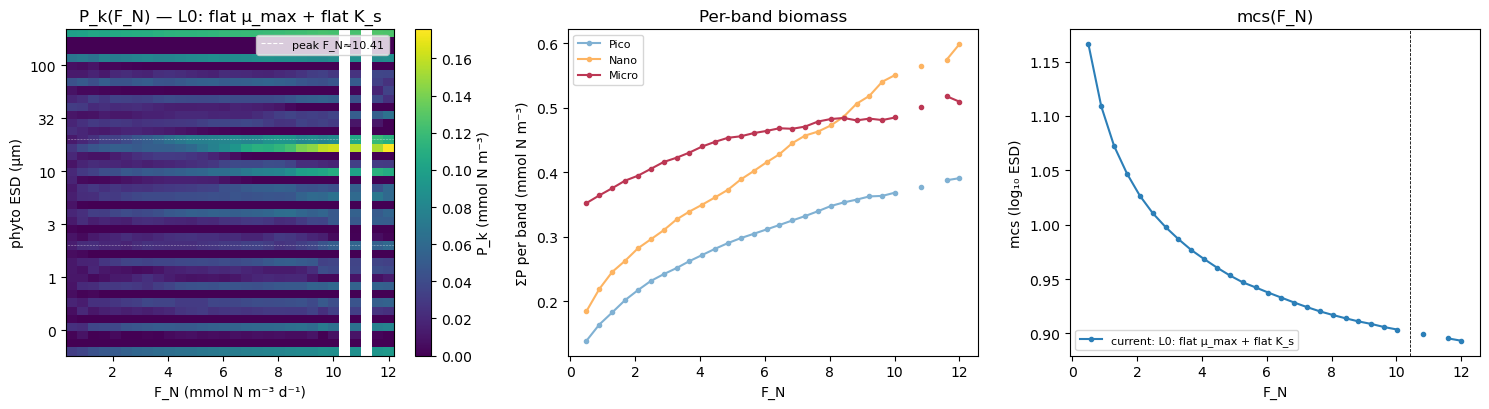


L0  peak F_N = 10.41   mcs range = [nan, nan]


In [7]:
# ---- Cell 1 — Layer 0: null baseline (flat μ_max AND flat K_s) -------------
# What this tests: does any mcs shape emerge with the growth allometric
# asymmetry switched off entirely? Without size-dependence in μ_max or K_s,
# every phyto class has identical specific growth at the same N.
# Literature anchor: slope theorem (Survey §18) says phyto allometry sets
# viability/extent; remove it and there is nothing to drive either limb.
# Expected (tentative): mcs ≈ flat in F_N; biomass scales roughly uniformly.
mu_max_flat = float(ns.mu_max_tani.mean())
ks_flat     = float(ns.ks_tani.mean())
print(f"Flat values used:  μ_max = {mu_max_flat:.3f} d⁻¹,  K_s = {ks_flat:.3f} mmol N m⁻³")

layer0 = run_layer(
    'L0: flat μ_max + flat K_s',
    {'Growth__mu_max':  np.full(n_P, mu_max_flat),
     'Growth__halfsat': np.full(n_P, ks_flat)},
)
plot_layer(layer0)
print(f"\nL0  peak F_N = {layer0['peak_FN']:.2f}   "
      f"mcs range = [{layer0['mcs'].min():.2f}, {layer0['mcs'].max():.2f}]")

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 26.95276 seconds.


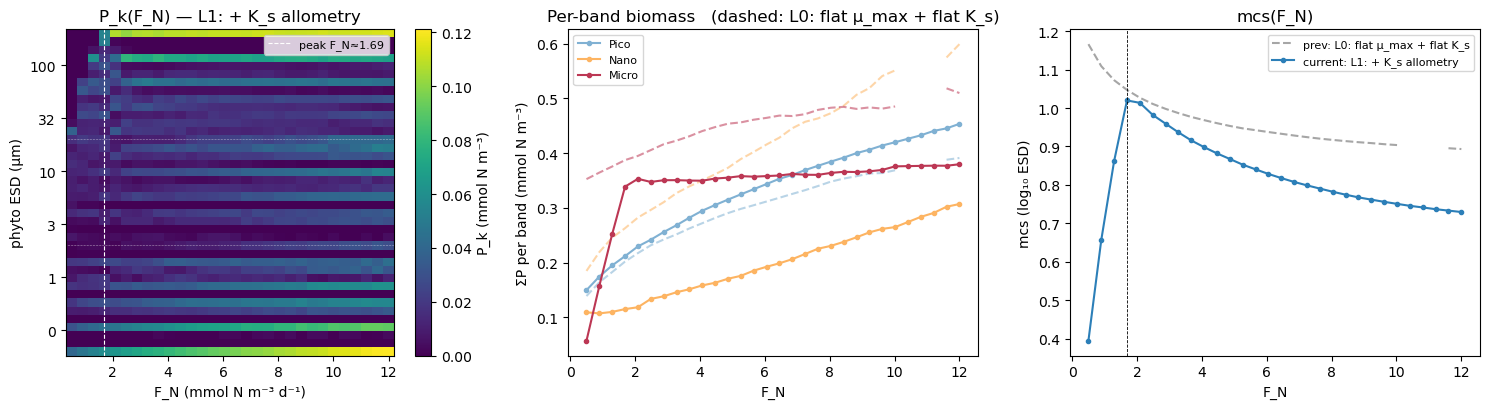


L1  peak F_N = 1.69   mcs range = [0.39, 1.02]


In [8]:
# ---- Cell 2 — Layer 1: add K_s allometry (μ_max still flat) ----------------
# What this tests: the truncation-extension story for the ASCENDING limb.
# With Taniguchi K_s ∝ s^+0.48, large cells need higher N to be viable; the
# 0-contour (μ(s,N) = m_P) climbs the size axis as F_N rises.
# Literature anchor: A&V 2023 Fig. 11, Taniguchi 2014 Fig. 4, Banas 2011
# Fig. 6 — nutrients extend the upper cutoff `m_max` more than they change
# slope (Survey §18 lines 444, 461).
# Expected (tentative): ascending limb appears as new Micro classes come on;
# descending limb absent or weak because flat μ_max removes the growth-rate
# asymmetry that drives Pico's competitive escape.
layer1 = run_layer(
    'L1: + K_s allometry',
    {'Growth__mu_max': np.full(n_P, mu_max_flat)},   # K_s reverts to Taniguchi default
)
plot_layer(layer1, previous=layer0)
print(f"\nL1  peak F_N = {layer1['peak_FN']:.2f}   "
      f"mcs range = [{layer1['mcs'].min():.2f}, {layer1['mcs'].max():.2f}]")

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 36.30776 seconds.


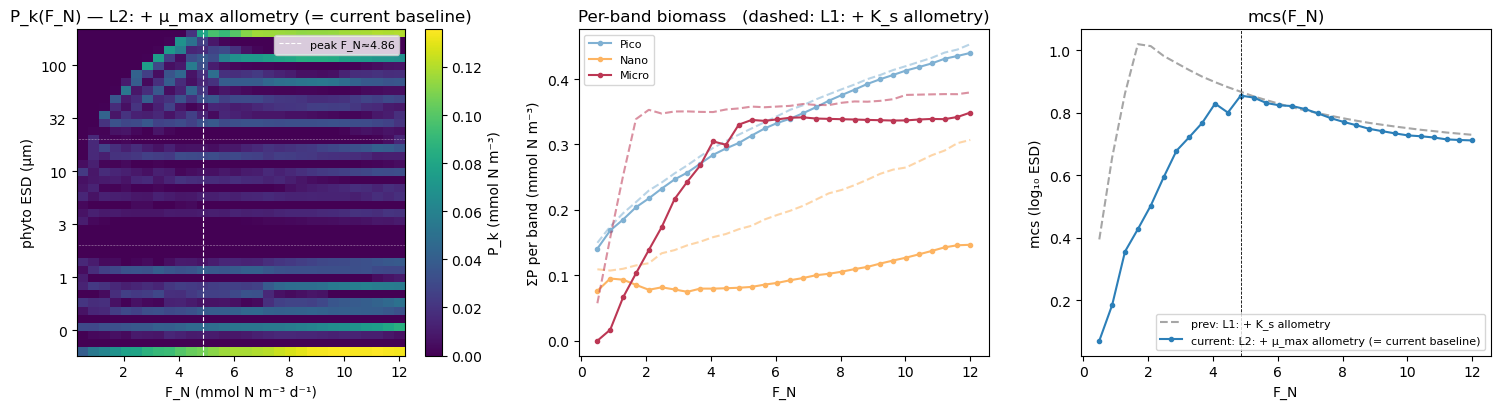


L2  peak F_N = 4.86   mcs range = [0.07, 0.86]


In [9]:
# ---- Cell 3 — Layer 2: add μ_max allometry (= full Taniguchi growth) -------
# What this tests: whether the descending limb appears once Pico has both
# higher μ_max AND lower K_s. This layer reproduces the current MS3 baseline.
# Literature framing: in the linear slope theorem (Survey §18 line 431),
# phyto μ_max drops out of P*(s); but MS3 is in Type III sub-threshold
# (quadratic in P, per Diagnostic A), so the linear theorem doesn't strictly
# apply and the phyto allometry can express itself through biomass
# equilibration rather than slope.
# Expected (tentative): descending limb appears; matches the unimodal mcs(F_N)
# we've been characterising in earlier cells.
layer2 = run_layer('L2: + μ_max allometry (= current baseline)', {})
plot_layer(layer2, previous=layer1)
print(f"\nL2  peak F_N = {layer2['peak_FN']:.2f}   "
      f"mcs range = [{layer2['mcs'].min():.2f}, {layer2['mcs'].max():.2f}]")

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 22.94682 seconds.


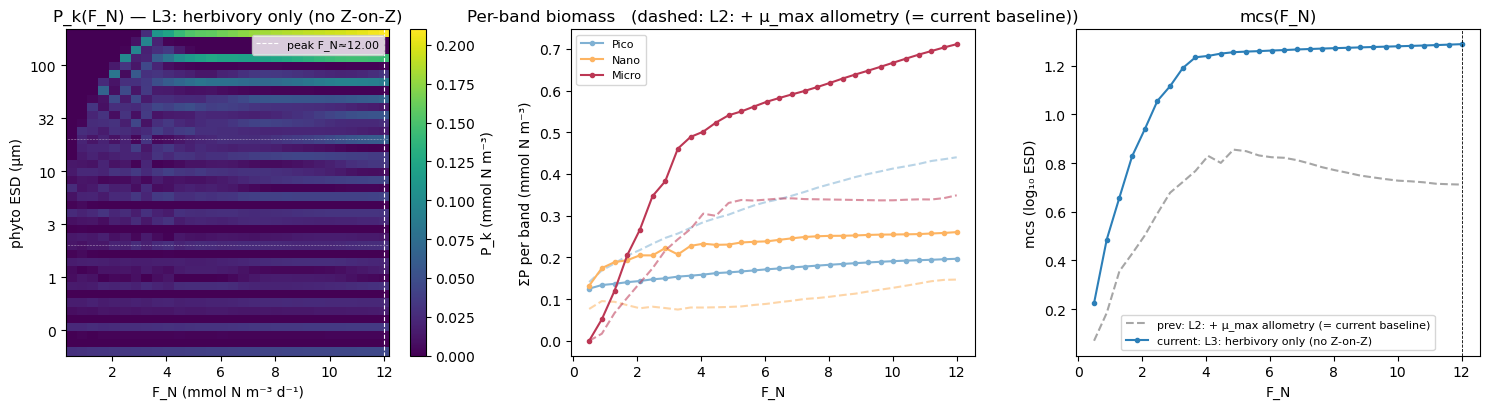


L3  peak F_N = 12.00   mcs range = [0.23, 1.29]


In [7]:
# ---- Cell 4 — Layer 3: drop omnivory (Taniguchi Model 2 equivalent) --------
# What this tests: is the descending limb the Taniguchi 2014 Model 3
# phenomenon (slope steepens with enrichment under Z-on-Z grazing)?
# Literature anchor: Survey §18 line 462 / §19 line 480 — Taniguchi Model 3
# slope (−1.04 to −1.17) is steeper than Models 1, 2 (−0.95 to −0.98) and the
# steepening is "exaggerated as nutrient concentration increases." Removing
# omnivory should weaken or eliminate the descending limb if the Model 3
# mechanism is the driver.
# Implementation: zero out zoo-prey rows of phiPZ so zoo only eat phyto.
# Expected (tentative): descending limb dampens, possibly substantially.
# If it persists at similar amplitude, the bottom-up Pico runaway is
# operating independently of omnivory in our sub-threshold regime.
phiPZ_herb = ns.phiPZ_omni.copy()
phiPZ_herb[n_P:, :] = 0.0          # zoo prey rows = 0 → no Z-on-Z grazing

layer3 = run_layer('L3: herbivory only (no Z-on-Z)', {'Grazing__phiPZ': phiPZ_herb})
plot_layer(layer3, previous=layer2)
print(f"\nL3  peak F_N = {layer3['peak_FN']:.2f}   "
      f"mcs range = [{layer3['mcs'].min():.2f}, {layer3['mcs'].max():.2f}]")

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 36.7593 seconds.


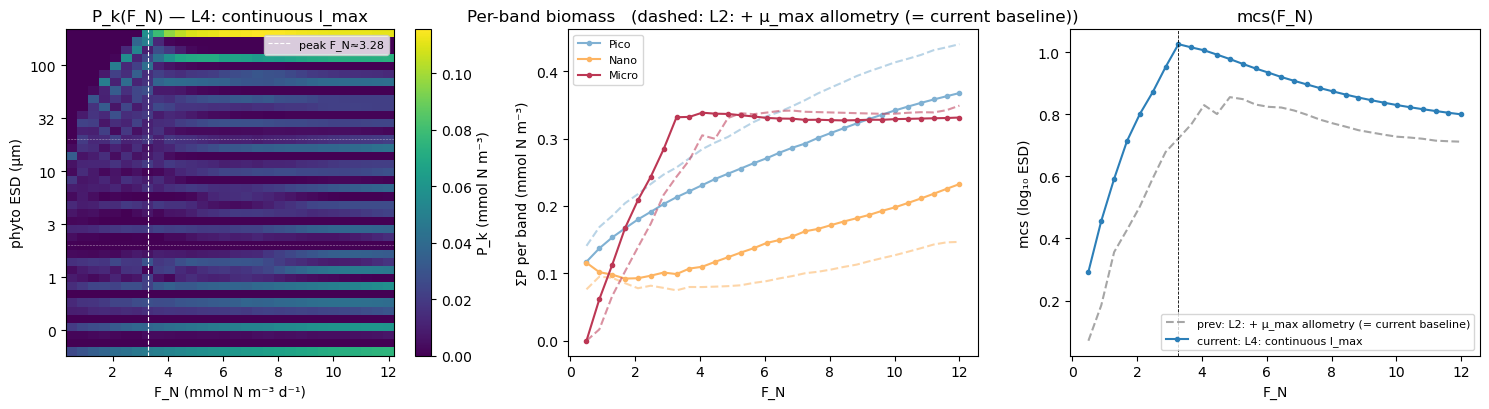


L4  peak F_N = 3.28   mcs range = [0.29, 1.03]


In [8]:
# ---- Cell 5 — Layer 4: continuous I_max allometry (no Dutkiewicz plateau) ----
# What this tests: same as the standalone Cell 15 earlier. Continue the Hansen
# I_max allometry through the whole zoo range instead of capping small zoo at
# 9.8 d⁻¹. Literature anchor: Dutkiewicz 2020 Suppl. Table S2 documents the
# plateau as a structural choice for microzoo (not metazoa allometry); removing
# it is a counterfactual to gauge the plateau's contribution, not a fix.
# Expected (tentative): descending limb amplitude reduced but not eliminated
# (we already saw the solid blue mcs still curls over in Cell 15).
zoo_vol   = (np.pi / 6.0) * ns.zoo_esd ** 3
Imax_cont = 30.9 * zoo_vol ** (-0.16)

layer4 = run_layer('L4: continuous I_max', {'Grazing__Imax': Imax_cont})
plot_layer(layer4, previous=layer2)
print(f"\nL4  peak F_N = {layer4['peak_FN']:.2f}   "
      f"mcs range = [{layer4['mcs'].min():.2f}, {layer4['mcs'].max():.2f}]")

L5a aggressive boost: Micro μ_max set uniformly to 1.76 d⁻¹ (vs original 0.71 d⁻¹ mean)
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 31.80601 seconds.


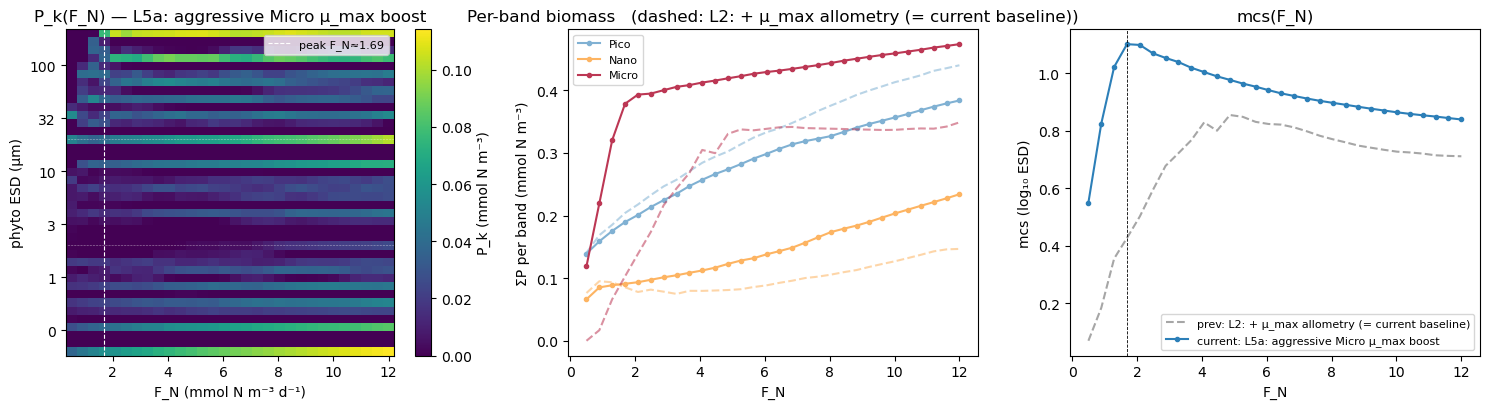


L5a  peak F_N = 1.69   mcs range = [0.55, 1.10]


In [9]:
# ---- Cell 6 — Layer 5a: aggressive diatom boost (Micro μ_max = Pico μ_max) --
# What this tests: the MECHANISTIC question of whether neutralising the
# growth-rate asymmetry between Pico and Micro removes the descending limb.
# Set μ_max for all Micro (>20 µm) phyto to the Pico-maximum value (Taniguchi
# at smallest grid size). NOT literature-defensible — diagnostic only.
# Expected (tentative): if the Pico runaway is what's driving the descending
# limb (rather than the omnivory loop alone), neutralising the asymmetry at
# the upper end should flatten or remove the limb.
mu_max_boost_aggressive = ns.mu_max_tani.copy()
mu_pico_max = float(ns.mu_max_tani[0])                                   # ≈ 1.52 d⁻¹
mu_max_boost_aggressive[m_micro] = mu_pico_max
print(f"L5a aggressive boost: Micro μ_max set uniformly to {mu_pico_max:.2f} d⁻¹ "
      f"(vs original {ns.mu_max_tani[m_micro].mean():.2f} d⁻¹ mean)")

layer5a = run_layer('L5a: aggressive Micro μ_max boost',
                    {'Growth__mu_max': mu_max_boost_aggressive})
plot_layer(layer5a, previous=layer2)
print(f"\nL5a  peak F_N = {layer5a['peak_FN']:.2f}   "
      f"mcs range = [{layer5a['mcs'].min():.2f}, {layer5a['mcs'].max():.2f}]")

L5b Mattern boost: Micro μ_max range = [1.15, 2.00] d⁻¹ (vs Taniguchi [0.58, 0.84] d⁻¹)
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 32.1158 seconds.


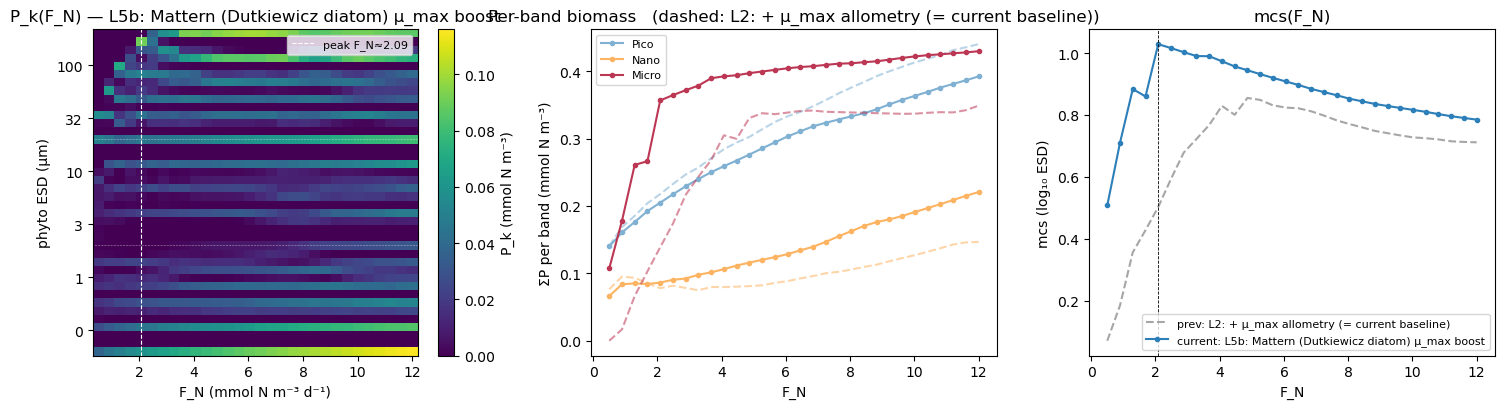


L5b  peak F_N = 2.09   mcs range = [0.51, 1.03]


In [10]:
# ---- Cell 7 — Layer 5b: Mattern-style diatom boost (Dutkiewicz allometry) --
# What this tests: a literature-defensible diatom μ_max boost. Replace μ_max
# for Micro (>20 µm) with the Dutkiewicz 2020 diatom-specific allometry
# (Survey §3: μ_max = 3.9·V^−0.08, vs the general Taniguchi 1.36·s^−0.16).
# At 50 µm ESD this gives ≈ 1.9 d⁻¹ instead of ≈ 0.77 d⁻¹.
# Literature anchor: Mattern 2026 uses Dutkiewicz 2020's per-group allometry;
# diatoms have their own (much higher) μ_max coefficient than the general
# allometry MS3 inherited from Taniguchi.
# Expected (tentative): softer effect than 5a — the diatom allometry still
# declines with size (just less steeply), so the asymmetry is reduced but
# not eliminated. The descending limb amplitude should shrink.
phyto_vol   = (np.pi / 6.0) * ns.phyto_esd ** 3
mu_diatom   = 3.9 * phyto_vol ** (-0.08)                                # Dutkiewicz 2020 diatom
mu_max_boost_mattern = ns.mu_max_tani.copy()
mu_max_boost_mattern[m_micro] = mu_diatom[m_micro]
print(f"L5b Mattern boost: Micro μ_max range = "
      f"[{mu_max_boost_mattern[m_micro].min():.2f}, "
      f"{mu_max_boost_mattern[m_micro].max():.2f}] d⁻¹ "
      f"(vs Taniguchi [{ns.mu_max_tani[m_micro].min():.2f}, "
      f"{ns.mu_max_tani[m_micro].max():.2f}] d⁻¹)")

layer5b = run_layer('L5b: Mattern (Dutkiewicz diatom) μ_max boost',
                    {'Growth__mu_max': mu_max_boost_mattern})
plot_layer(layer5b, previous=layer2)
print(f"\nL5b  peak F_N = {layer5b['peak_FN']:.2f}   "
      f"mcs range = [{layer5b['mcs'].min():.2f}, {layer5b['mcs'].max():.2f}]")

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 33.23209 seconds.


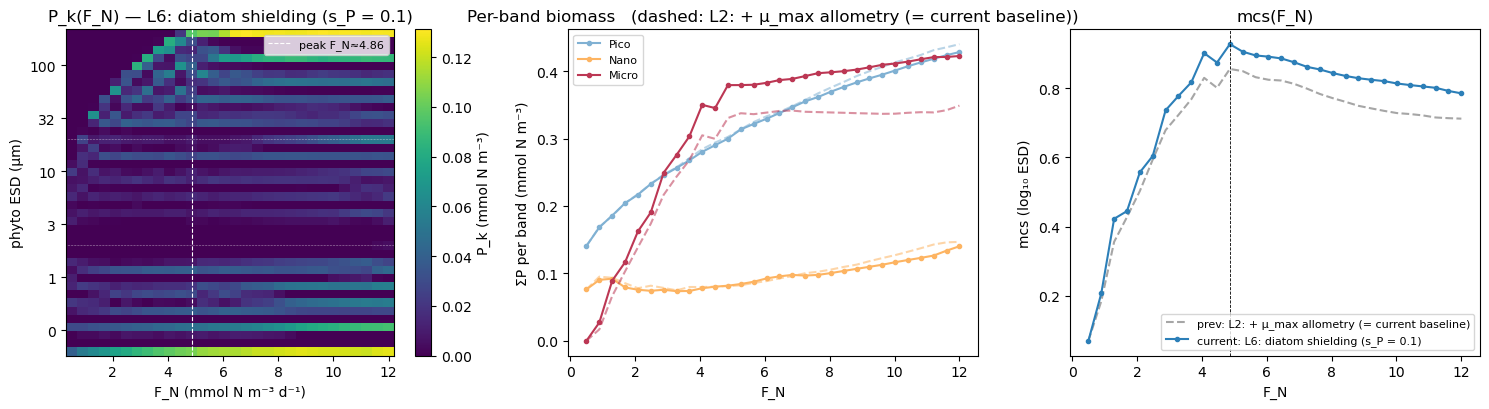


L6  peak F_N = 4.86   mcs range = [0.07, 0.93]


In [11]:
# ---- Cell 8 — Layer 6: diatom shielding (s_P = 0.1 on Micro phyto rows) -----
# What this tests: Mattern 2026's other lever — reduce the palatability of
# Micro phyto (diatoms) by 10% in the kernel, representing protection from
# grazing via hardened cell walls / silicate frustules.
# Literature anchor: Mattern 2026 Eq. 5; Survey §17. Cariaco Micro is
# diatom-dominated (Lorenzoni 2015) so this is biologically defensible.
# Implementation: multiply Micro prey rows of phiPZ by (1 − s_P) = 0.9.
# Affects BOTH herbivory and the omnivory loop (zoo grazing on Micro).
# Expected (tentative): partial dampening of the descending limb — weaker
# than the growth boost because Micro grazing is already sub-threshold;
# reducing it by 10% reduces an already-small loss term.
s_P_diatom = 0.1
phiPZ_shield = ns.phiPZ_omni.copy()
phiPZ_shield[:n_P][m_micro, :] *= (1.0 - s_P_diatom)         # Micro phyto prey rows

layer6 = run_layer('L6: diatom shielding (s_P = 0.1)',
                   {'Grazing__phiPZ': phiPZ_shield})
plot_layer(layer6, previous=layer2)
print(f"\nL6  peak F_N = {layer6['peak_FN']:.2f}   "
      f"mcs range = [{layer6['mcs'].min():.2f}, {layer6['mcs'].max():.2f}]")

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 35.99875 seconds.


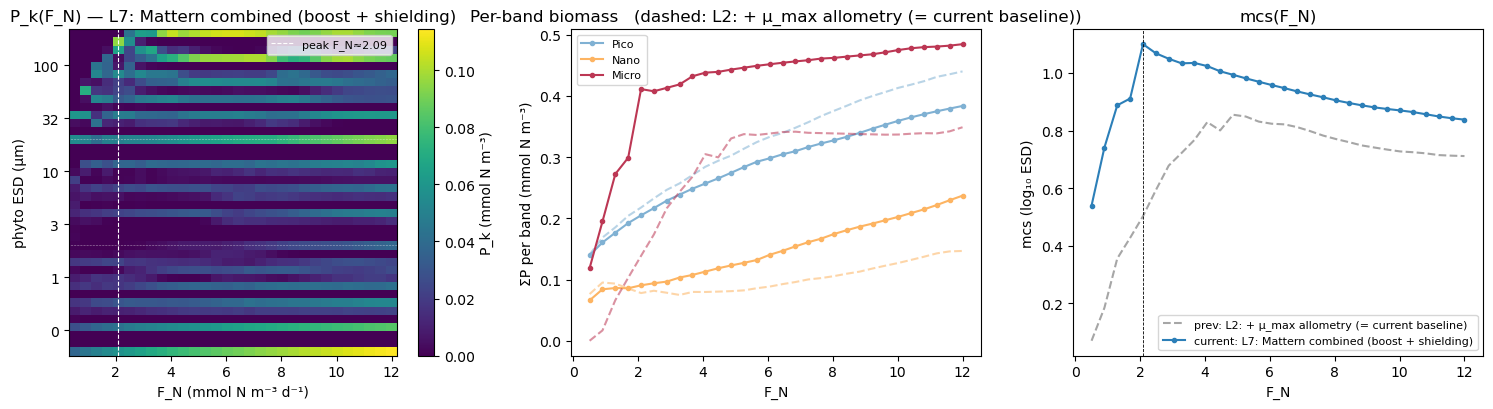


L7  peak F_N = 2.09   mcs range = [0.54, 1.10]


In [12]:
# ---- Cell 9 — Layer 7: Mattern combined (diatom boost + shielding) ---------
# What this tests: the full Mattern 2026 prescription — diatom μ_max boost
# (Dutkiewicz allometry on Micro) AND diatom shielding (s_P = 0.1) applied
# together. This is the literature-defensible construct that fixes both the
# growth-rate asymmetry and the omnivory pressure on Micro simultaneously.
# Expected (tentative): the combined effect should be the most monotonic
# mcs(F_N) of the modification-pass layers, plausibly matching the
# herbivory-only Layer 3 result without actually dropping omnivory.
layer7 = run_layer(
    'L7: Mattern combined (boost + shielding)',
    {'Growth__mu_max':  mu_max_boost_mattern,
     'Grazing__phiPZ':  phiPZ_shield},
)
plot_layer(layer7, previous=layer2)
print(f"\nL7  peak F_N = {layer7['peak_FN']:.2f}   "
      f"mcs range = [{layer7['mcs'].min():.2f}, {layer7['mcs'].max():.2f}]")

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 27.66874 seconds.


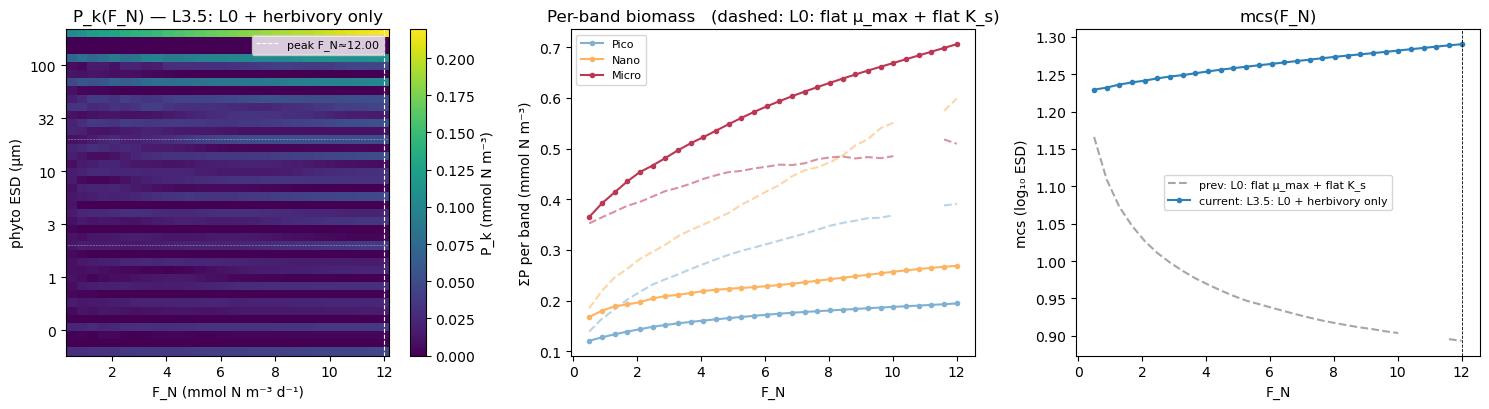


L3.5  peak F_N = 12.00   mcs range = [1.23, 1.29]


In [13]:
# ---- Cell 10 — Layer 3.5: L0 + herbivory only (isolate omnivory in L0) ----
# What this tests: in the flat-allometry baseline (L0), is the residual
# descending slant driven by omnivory ALONE, or do other grazer-side
# components (I_max allometry, kernel structure, closure) contribute?
# Expected (tentative): if monotonic → omnivory is the lone driver in L0,
# the descending limb is structurally tied to the omnivory loop independent
# of phyto allometry. If still declining → I_max allometry shares the load.
phiPZ_herb_l0 = ns.phiPZ_omni.copy()
phiPZ_herb_l0[n_P:, :] = 0.0

layer3_5 = run_layer(
    'L3.5: L0 + herbivory only',
    {'Growth__mu_max':  np.full(n_P, mu_max_flat),
     'Growth__halfsat': np.full(n_P, ks_flat),
     'Grazing__phiPZ':  phiPZ_herb_l0},
)
plot_layer(layer3_5, previous=layer0)
print(f"\nL3.5  peak F_N = {layer3_5['peak_FN']:.2f}   "
      f"mcs range = [{layer3_5['mcs'].min():.2f}, {layer3_5['mcs'].max():.2f}]")

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd_banas' and setup 'model_setup_npzd_banas_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 35.37762 seconds.


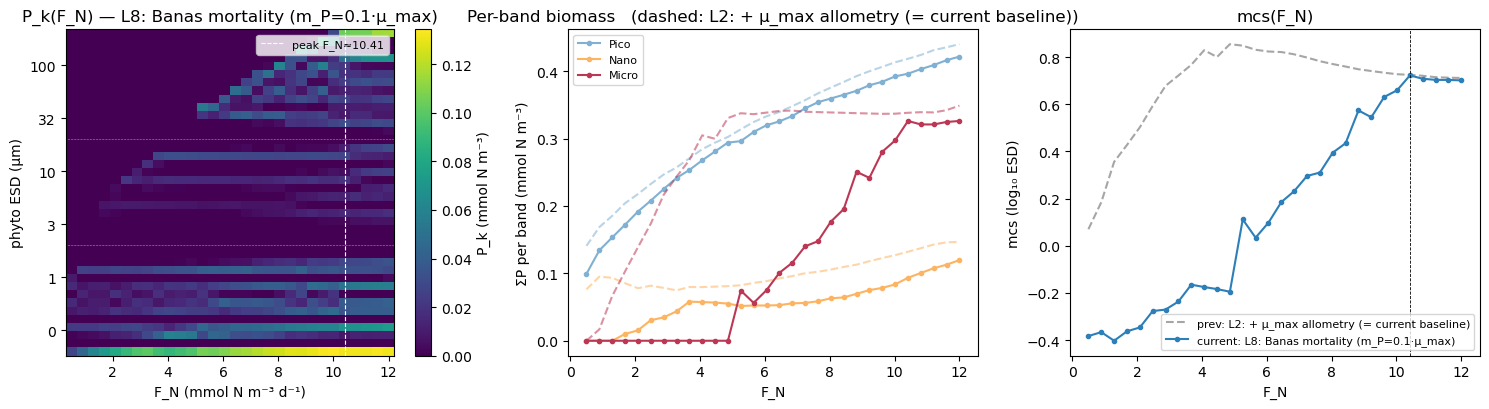


L8  peak F_N = 10.41   mcs range = [-0.40, 0.72]


In [14]:
# ---- Cell 11 — Layer 8: Banas mortality (m_P = 0.1·μ_max(Tani)) ------------
# Uses the model_npzd_banas variant whose PhytoMortality is
# m_P = coeff · μ_max (foreign-referenced); coeff = 0.1 (Banas standard).
# Built on top of Taniguchi growth so the mortality form is the only change
# from L2 baseline. Note: Banas mortality scales WITH μ_max, so it hits
# fast-growing (small) cells HARDER than slow-growing (large) cells —
# which means it should partially counter the Pico runaway.
# Expected (tentative): Pico biomass reduced (more mortality on small cells);
# Micro biomass roughly unchanged (their mortality is small because μ_max
# is small for large cells); descending limb amplitude reduced if the Pico
# runaway is responsible. Watch the peak position.
banas_overrides = {k: v for k, v in BASE_OVERRIDES.items()
                   if k != 'PhytoMortality__rate'}
banas_overrides['PhytoMortality__coeff'] = 0.1

scan_b = run_xso_parscan(
    model_file_name='cariaco_npzd_setups',
    model_name='model_npzd_banas',
    model_setup_name='model_setup_npzd_banas_scan',
    param_name='Inflow__FN',
    param_values=FN_VALUES,
    fixed_overrides=banas_overrides,
    postprocess_name='avg_tail',
    postprocess_kwargs={'avg_window': 1000},
    processes=8,
)
order_b = np.argsort(scan_b['Inflow__FN'].values)
FN_b = scan_b['Inflow__FN'].values[order_b]
P_b  = scan_b['Phytoplankton__biomass'].squeeze('time').values[order_b]
Z_b  = scan_b['Zooplankton__biomass'].squeeze('time').values[order_b]
N_b  = scan_b['Nutrient__value'].squeeze('time').values[order_b]
mcs_b = (P_b * np.log10(ns.phyto_esd)[None, :]).sum(axis=1) / np.maximum(P_b.sum(axis=1), 1e-30)
pk_b = int(np.argmax(mcs_b))
layer8 = dict(
    label='L8: Banas mortality (m_P=0.1·μ_max)',
    FN=FN_b, P=P_b, Z=Z_b, N=N_b, mcs=mcs_b,
    peak_idx=pk_b, peak_FN=FN_b[pk_b],
    P_pico=P_b[:, m_pico].sum(axis=1),
    P_nano=P_b[:, m_nano].sum(axis=1),
    P_micro=P_b[:, m_micro].sum(axis=1),
)
plot_layer(layer8, previous=layer2)
print(f"\nL8  peak F_N = {layer8['peak_FN']:.2f}   "
      f"mcs range = [{layer8['mcs'].min():.2f}, {layer8['mcs'].max():.2f}]")

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=84.6 on P[3] = -0.00155. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=787.3 on P[0] = -0.00225. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=240.5 on P[7] = -0.00105. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'

1D Scan complete. Time taken: 56.872 seconds.


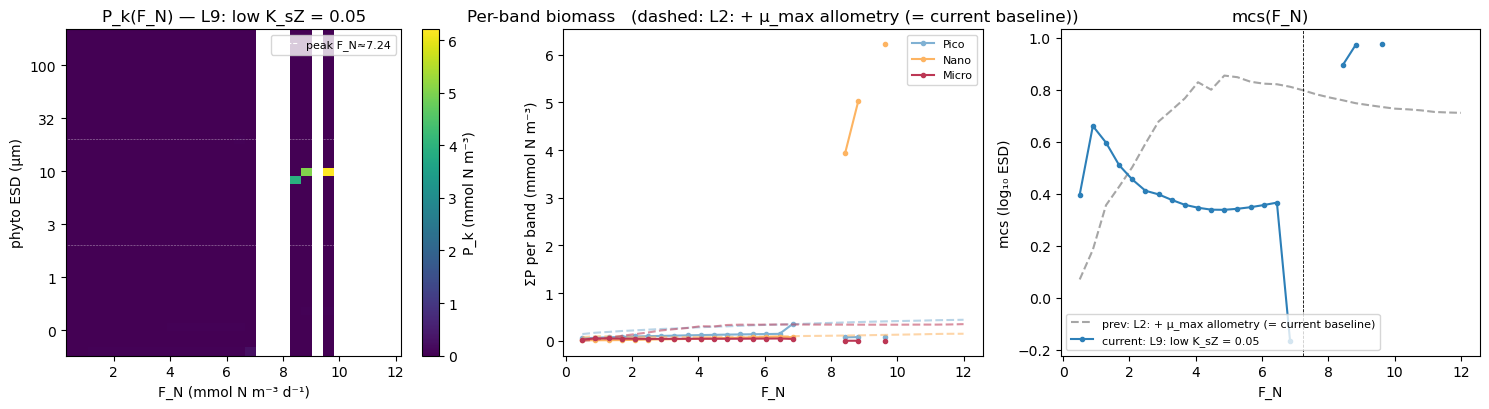


L9  peak F_N = 7.24   mcs range = [nan, nan]


In [15]:
# ---- Cell 12 — Layer 9: lower K_sZ (push grazing past Type III threshold) --
# What this tests: drop K_sZ from 0.23 to 0.05 mmol N. At that level S_j
# should exceed K_sZ for the smallest-phyto predators across most of the F_N
# range (per Diagnostic A — they were at S ≈ 0.05–0.15 across the scan).
# The kill-the-winner cascade should fire on Pico for the first time in our
# scans. Anderson 2010 / Prowe 2012 mechanism in literal form.
# Expected (tentative): Pico biomass is held in check (small zoo saturate
# and crop Pico effectively), N rises faster, Micro lifts; descending limb
# weakens or removes.
KsZ_low = 0.05
layer9 = run_layer(f'L9: low K_sZ = {KsZ_low}',
                   {'Grazing__KsZ': np.full(n_Z, KsZ_low)})
plot_layer(layer9, previous=layer2)
print(f"\nL9  peak F_N = {layer9['peak_FN']:.2f}   "
      f"mcs range = [{layer9['mcs'].min():.2f}, {layer9['mcs'].max():.2f}]")

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 30.16854 seconds.


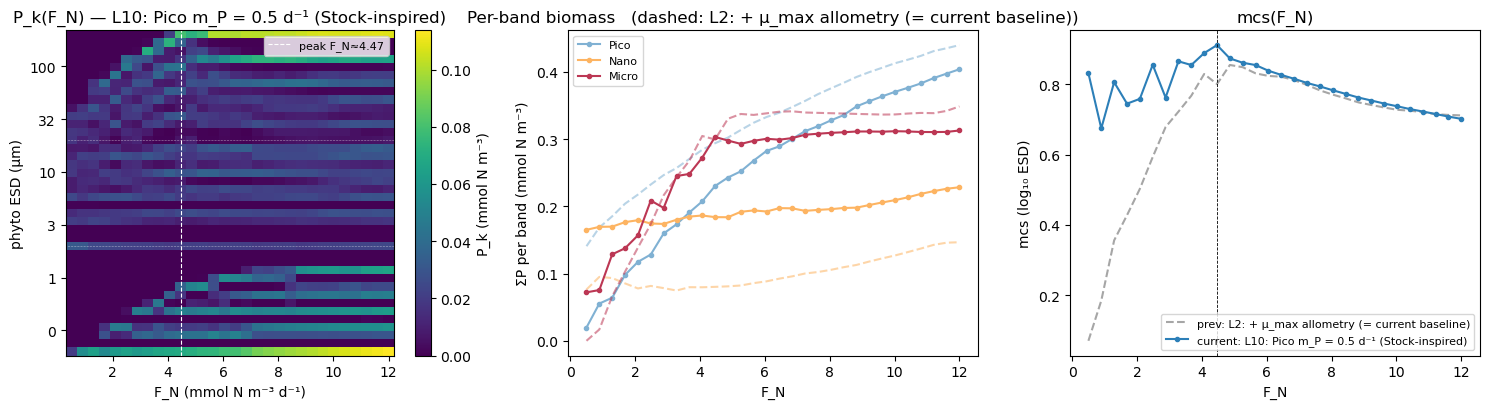


L10  peak F_N = 4.47   mcs range = [0.67, 0.91]


In [16]:
# ---- Cell 13 — Layer 10: Pico-elevated mortality (Stock 2008-inspired) ----
# What this tests: Stock 2008 §3.4 P₁² squared mortality on small phyto is
# the canonical literature lever for breaking small-cell runaways. A true
# squared term would need a code edit (PhytoMortality_route is currently
# linear). First-pass: elevated LINEAR m_P on Pico classes only (0.5 d⁻¹
# on Pico, 0.02 on Nano + Micro). Tests the mechanism *intent*, not the
# exact functional form.
# Expected (tentative): Pico biomass should drop noticeably; N should rise;
# Micro should lift. If the descending limb softens with this linear
# approximation, a true P² implementation would be worth the code edit.
m_P_pico_hi = np.full(n_P, 0.02)
m_P_pico_hi[m_pico] = 0.5

layer10 = run_layer('L10: Pico m_P = 0.5 d⁻¹ (Stock-inspired)',
                    {'PhytoMortality__rate': m_P_pico_hi})
plot_layer(layer10, previous=layer2)
print(f"\nL10  peak F_N = {layer10['peak_FN']:.2f}   "
      f"mcs range = [{layer10['mcs'].min():.2f}, {layer10['mcs'].max():.2f}]")

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 26.3177 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 30.89475 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
------------------------

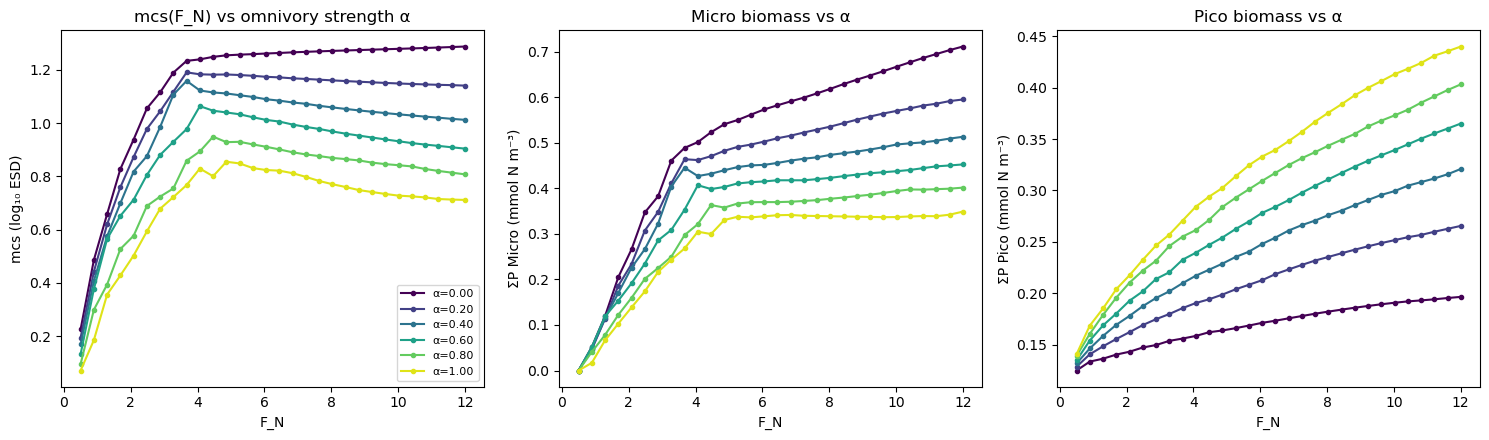

  α=0.00:  peak F_N = 12.00   mcs range = [0.23, 1.29]
  α=0.20:  peak F_N =  3.67   mcs range = [0.19, 1.19]
  α=0.40:  peak F_N =  3.67   mcs range = [0.17, 1.16]
  α=0.60:  peak F_N =  4.07   mcs range = [0.13, 1.06]
  α=0.80:  peak F_N =  4.47   mcs range = [0.09, 0.95]
  α=1.00:  peak F_N =  4.86   mcs range = [0.07, 0.86]


In [17]:
# ---- Cell 14 — Partial omnivory α-scan: herbivory → full omnivory ---------
# Scale the zoo-prey rows of phiPZ by α ∈ [0, 1]:
#   α = 0  → pure herbivory (= L3)
#   α = 1  → full omnivory (= L2 baseline)
# Quantifies how the descending limb amplitude varies with omnivory strength.
alphas_omni = np.linspace(0.0, 1.0, 6)
results_omni = []
for a in alphas_omni:
    phiPZ_partial = ns.phiPZ_omni.copy()
    phiPZ_partial[n_P:, :] *= a
    res = run_layer(f'α={a:.2f}', {'Grazing__phiPZ': phiPZ_partial})
    results_omni.append(res)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
colors = plt.cm.viridis(np.linspace(0.0, 0.95, len(alphas_omni)))

for res, col, a in zip(results_omni, colors, alphas_omni):
    axes[0].plot(res['FN'], res['mcs'], '-o', color=col, label=f'α={a:.2f}', ms=3)
axes[0].set_xlabel('F_N'); axes[0].set_ylabel('mcs (log₁₀ ESD)')
axes[0].set_title('mcs(F_N) vs omnivory strength α')
axes[0].legend(fontsize=8, loc='lower right')

for res, col in zip(results_omni, colors):
    axes[1].plot(res['FN'], res['P_micro'], '-o', color=col, ms=3)
axes[1].set_xlabel('F_N'); axes[1].set_ylabel('ΣP Micro (mmol N m⁻³)')
axes[1].set_title('Micro biomass vs α')

for res, col in zip(results_omni, colors):
    axes[2].plot(res['FN'], res['P_pico'], '-o', color=col, ms=3)
axes[2].set_xlabel('F_N'); axes[2].set_ylabel('ΣP Pico (mmol N m⁻³)')
axes[2].set_title('Pico biomass vs α')
plt.tight_layout(); plt.show()

for res, a in zip(results_omni, alphas_omni):
    print(f"  α={a:.2f}:  peak F_N = {res['peak_FN']:5.2f}   "
          f"mcs range = [{res['mcs'].min():.2f}, {res['mcs'].max():.2f}]")

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd_banas' and setup 'model_setup_npzd_banas_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 34.07387 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd_banas' and setup 'model_setup_npzd_banas_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 35.37345 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd_banas' and setup 'model_setup_npzd_banas_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--

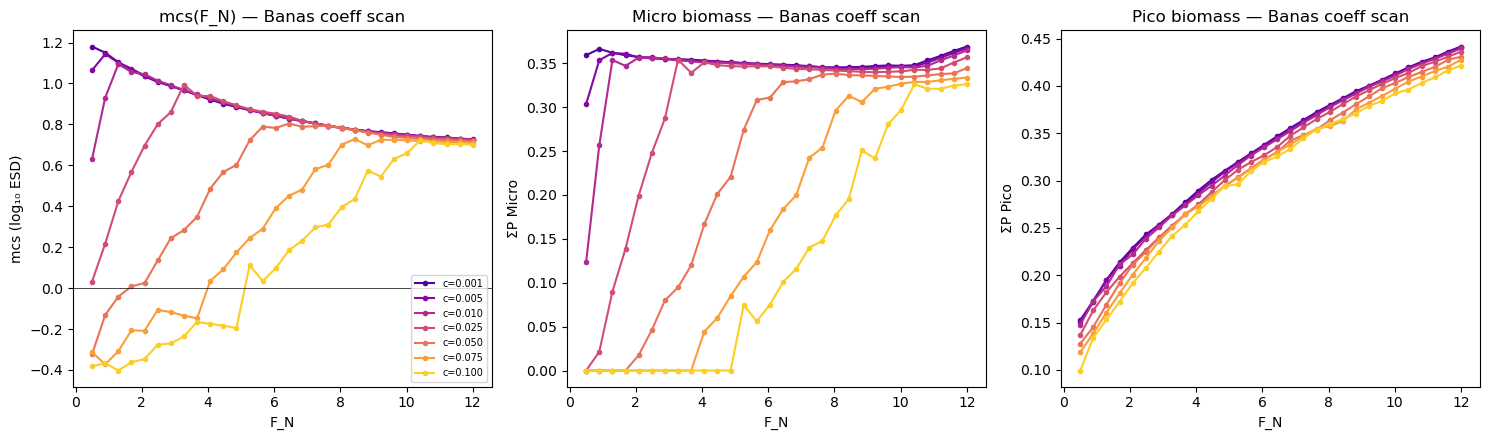

  coeff=0.001:  peak F_N =  0.50   mcs range = [0.73, 1.18]   Micro(F_N=12)=0.369
  coeff=0.005:  peak F_N =  0.90   mcs range = [0.73, 1.14]   Micro(F_N=12)=0.367
  coeff=0.010:  peak F_N =  1.29   mcs range = [0.63, 1.09]   Micro(F_N=12)=0.365
  coeff=0.025:  peak F_N =  3.28   mcs range = [0.03, 0.99]   Micro(F_N=12)=0.357
  coeff=0.050:  peak F_N =  6.45   mcs range = [-0.32, 0.80]   Micro(F_N=12)=0.344
  coeff=0.075:  peak F_N =  8.43   mcs range = [-0.37, 0.73]   Micro(F_N=12)=0.334
  coeff=0.100:  peak F_N = 10.41   mcs range = [-0.40, 0.72]   Micro(F_N=12)=0.326


In [18]:
# ---- Cell 15 — Banas mortality coefficient scan (0.001 → 0.1) -------------
banas_coeffs = [0.001, 0.005, 0.01, 0.025, 0.05, 0.075, 0.1]
results_banas = []

for coeff in banas_coeffs:
    overrides = {k: v for k, v in BASE_OVERRIDES.items()
                 if k != 'PhytoMortality__rate'}
    overrides['PhytoMortality__coeff'] = coeff
    scan = run_xso_parscan(
        model_file_name='cariaco_npzd_setups',
        model_name='model_npzd_banas',
        model_setup_name='model_setup_npzd_banas_scan',
        param_name='Inflow__FN',
        param_values=FN_VALUES,
        fixed_overrides=overrides,
        postprocess_name='avg_tail',
        postprocess_kwargs={'avg_window': 1000},
        processes=8,
    )
    o   = np.argsort(scan['Inflow__FN'].values)
    FN_ = scan['Inflow__FN'].values[o]
    P_  = scan['Phytoplankton__biomass'].squeeze('time').values[o]
    N_  = scan['Nutrient__value'].squeeze('time').values[o]
    mcs_= (P_ * np.log10(ns.phyto_esd)[None, :]).sum(axis=1) / np.maximum(P_.sum(axis=1), 1e-30)
    results_banas.append(dict(
        coeff=coeff, FN=FN_, mcs=mcs_, N=N_,
        P_pico=P_[:, m_pico].sum(axis=1),
        P_nano=P_[:, m_nano].sum(axis=1),
        P_micro=P_[:, m_micro].sum(axis=1),
    ))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
colors_b = plt.cm.plasma(np.linspace(0.15, 0.9, len(banas_coeffs)))

for res, col in zip(results_banas, colors_b):
    axes[0].plot(res['FN'], res['mcs'], '-o', color=col,
                 label=f"c={res['coeff']:.3f}", ms=3)
axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_xlabel('F_N'); axes[0].set_ylabel('mcs (log₁₀ ESD)')
axes[0].set_title('mcs(F_N) — Banas coeff scan')
axes[0].legend(fontsize=7, loc='lower right')

for res, col in zip(results_banas, colors_b):
    axes[1].plot(res['FN'], res['P_micro'], '-o', color=col, ms=3)
axes[1].set_xlabel('F_N'); axes[1].set_ylabel('ΣP Micro')
axes[1].set_title('Micro biomass — Banas coeff scan')

for res, col in zip(results_banas, colors_b):
    axes[2].plot(res['FN'], res['P_pico'], '-o', color=col, ms=3)
axes[2].set_xlabel('F_N'); axes[2].set_ylabel('ΣP Pico')
axes[2].set_title('Pico biomass — Banas coeff scan')
plt.tight_layout(); plt.show()

for res in results_banas:
    pk = int(np.argmax(res['mcs']))
    print(f"  coeff={res['coeff']:.3f}:  peak F_N = {res['FN'][pk]:5.2f}   "
          f"mcs range = [{res['mcs'].min():.2f}, {res['mcs'].max():.2f}]   "
          f"Micro(F_N=12)={res['P_micro'][-1]:.3f}")

Banas mean m_P (used for linear-equivalent): 0.107 d⁻¹
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 42.27426 seconds.


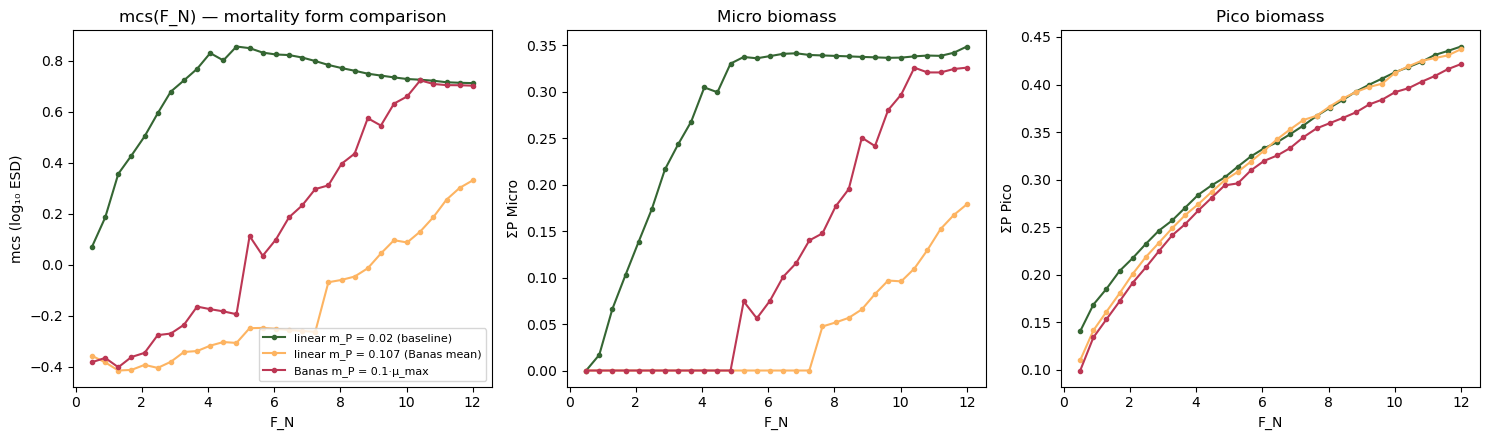

In [19]:
# ---- Cell 16 — Banas vs linear mortality direct comparison ----------------
# Side-by-side: pure linear (uniform m_P = 0.02 — current baseline / L2) vs
# Banas (m_P = 0.1·μ_max — L8). Plus a "scaled linear" at the Banas mean
# magnitude (≈ Banas-mean) to disentangle "size-dependent shape" from "mean
# magnitude" — if a uniform-linear at the Banas mean reproduces Banas, the
# shape doesn't matter; if it doesn't, the size dependence is the lever.
m_P_banas_mean = float((0.1 * ns.mu_max_tani).mean())
print(f"Banas mean m_P (used for linear-equivalent): {m_P_banas_mean:.3f} d⁻¹")

linear_low  = layer2     # already in memory: uniform 0.02 baseline (= L2)
linear_eq   = run_layer(f'linear m_P = {m_P_banas_mean:.3f}',
                        {'PhytoMortality__rate': np.full(n_P, m_P_banas_mean)})
banas_full  = layer8     # already in memory: Banas coeff=0.1 (= L8)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for res, col, lbl in [(linear_low, '#356633', 'linear m_P = 0.02 (baseline)'),
                      (linear_eq,  '#fdb462', f'linear m_P = {m_P_banas_mean:.3f} (Banas mean)'),
                      (banas_full, '#bc3754', 'Banas m_P = 0.1·μ_max')]:
    axes[0].plot(res['FN'], res['mcs'],     '-o', color=col, label=lbl, ms=3)
    axes[1].plot(res['FN'], res['P_micro'], '-o', color=col, ms=3)
    axes[2].plot(res['FN'], res['P_pico'],  '-o', color=col, ms=3)
axes[0].set_xlabel('F_N'); axes[0].set_ylabel('mcs (log₁₀ ESD)')
axes[0].set_title('mcs(F_N) — mortality form comparison'); axes[0].legend(fontsize=8)
axes[1].set_xlabel('F_N'); axes[1].set_ylabel('ΣP Micro'); axes[1].set_title('Micro biomass')
axes[2].set_xlabel('F_N'); axes[2].set_ylabel('ΣP Pico'); axes[2].set_title('Pico biomass')
plt.tight_layout(); plt.show()

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=92.63 on P[10] = -0.00133. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=196.3 on P[5] = -0.00115. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=167.6 on P[2] = -0.00114. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs=

1D Scan complete. Time taken: 40.26527 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 39.74416 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 37.32933 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successfu

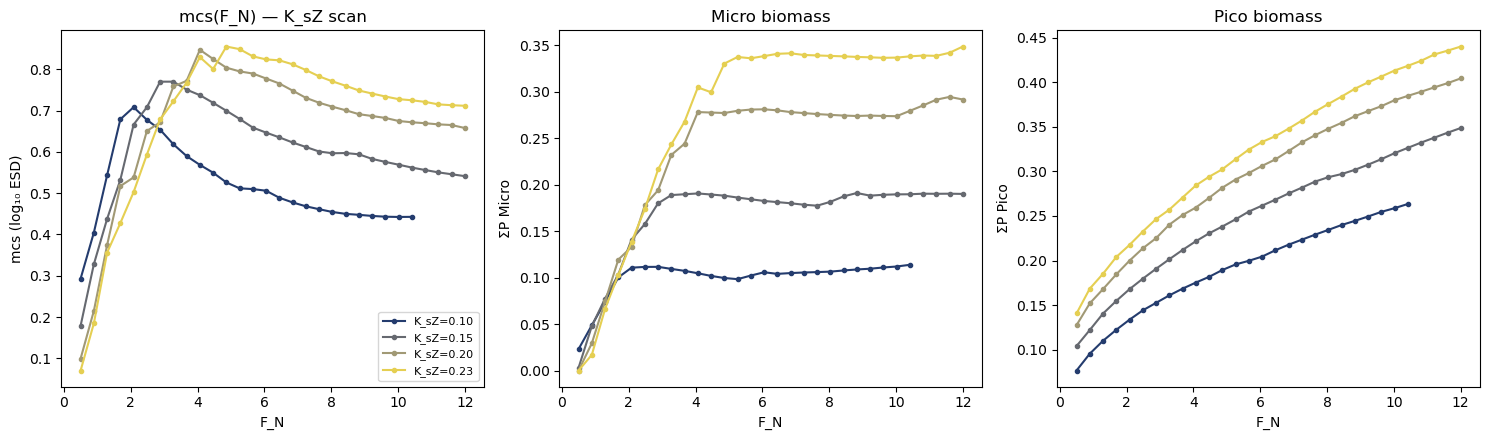

  K_sZ=0.10:  peak F_N = 10.81   mcs range = [nan, nan]
  K_sZ=0.15:  peak F_N =  3.28   mcs range = [0.18, 0.77]
  K_sZ=0.20:  peak F_N =  4.07   mcs range = [0.10, 0.85]
  K_sZ=0.23:  peak F_N =  4.86   mcs range = [0.07, 0.86]


In [20]:
# ---- Cell 17 — K_sZ retry at safer values (0.10, 0.15, 0.20, 0.23) --------
# 0.05 (L9) was a solver failure. Test less aggressive reductions to see
# whether moving partially toward the Type III saturated regime affects
# mcs(F_N) shape without numerical instability.
KsZ_values = [0.10, 0.15, 0.20, 0.23]                       # 0.23 = baseline
results_KsZ = []
for KsZ in KsZ_values:
    res = run_layer(f'K_sZ = {KsZ:.2f}',
                    {'Grazing__KsZ': np.full(n_Z, KsZ)})
    results_KsZ.append((KsZ, res))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
colors_K = plt.cm.cividis(np.linspace(0.15, 0.9, len(KsZ_values)))
for (KsZ, res), col in zip(results_KsZ, colors_K):
    axes[0].plot(res['FN'], res['mcs'],     '-o', color=col, label=f'K_sZ={KsZ:.2f}', ms=3)
    axes[1].plot(res['FN'], res['P_micro'], '-o', color=col, ms=3)
    axes[2].plot(res['FN'], res['P_pico'],  '-o', color=col, ms=3)
axes[0].set_xlabel('F_N'); axes[0].set_ylabel('mcs (log₁₀ ESD)')
axes[0].set_title('mcs(F_N) — K_sZ scan'); axes[0].legend(fontsize=8)
axes[1].set_xlabel('F_N'); axes[1].set_ylabel('ΣP Micro'); axes[1].set_title('Micro biomass')
axes[2].set_xlabel('F_N'); axes[2].set_ylabel('ΣP Pico'); axes[2].set_title('Pico biomass')
plt.tight_layout(); plt.show()
for KsZ, res in results_KsZ:
    pk = int(np.argmax(res['mcs']))
    print(f"  K_sZ={KsZ:.2f}:  peak F_N = {res['FN'][pk]:5.2f}   "
          f"mcs range = [{res['mcs'].min():.2f}, {res['mcs'].max():.2f}]")

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 36.10259 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 38.46109 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
-----------------------

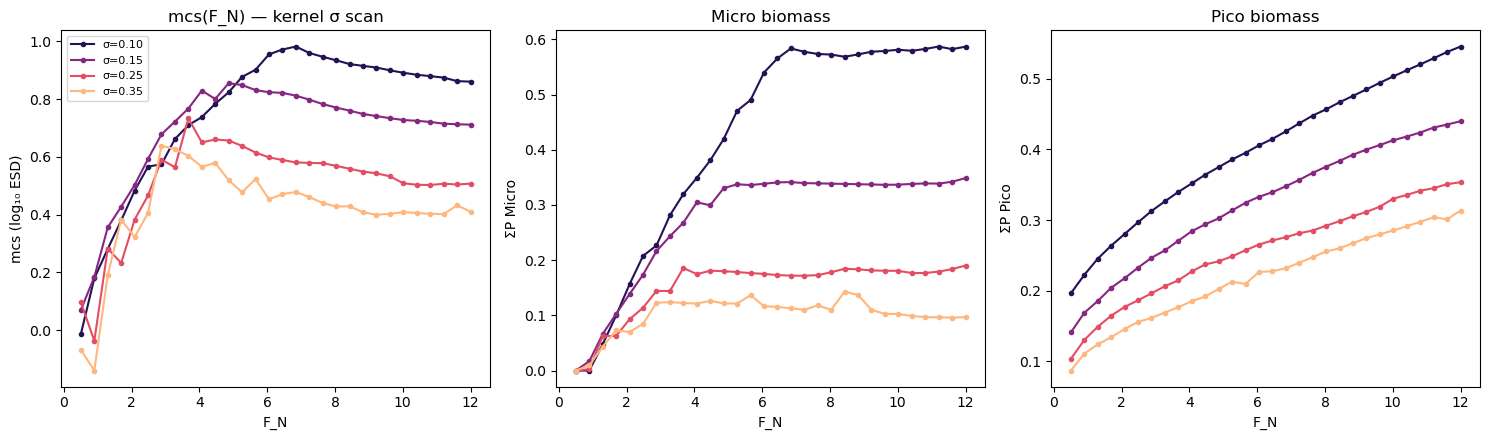

  σ=0.10:  peak F_N =  6.84   mcs range = [-0.01, 0.98]
  σ=0.15:  peak F_N =  4.86   mcs range = [0.07, 0.86]
  σ=0.25:  peak F_N =  3.67   mcs range = [-0.04, 0.73]
  σ=0.35:  peak F_N =  2.88   mcs range = [-0.14, 0.64]


In [22]:
# ---- Cell 18 — Kernel σ scan (feeding-kernel width) ----------------------
# Width of the Mattern log-Gaussian preference kernel. Baseline σ = 0.15
# (narrow = strong size-matching). Wider σ → predators eat a broader prey
# size range → more interference between adjacent prey classes.
# Test σ ∈ {0.10, 0.15, 0.25, 0.35}. 0.15 is Mattern; 0.30 is Mattern's
# widened-kernel SI experiment; Banas uses Δx_prey = 0.25 in the /Δx² form
# (equiv. σ ≈ 0.18 in 2σ²); A&V uses σ ≈ 0.56.
from cariaco_npzd_comps import compute_grazing_kernel
sigma_values = [0.10, 0.15, 0.25, 0.35]
results_sigma = []
for sigma in sigma_values:
    phiPZ_sigma = compute_grazing_kernel(ns.phyto_esd, ns.zoo_esd, mode='omni',
                                         sigma_log=sigma, theta_opt=10.0)
    res = run_layer(f'σ = {sigma:.2f}', {'Grazing__phiPZ': phiPZ_sigma})
    results_sigma.append((sigma, res))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
colors_s = plt.cm.magma(np.linspace(0.15, 0.85, len(sigma_values)))
for (sigma, res), col in zip(results_sigma, colors_s):
    axes[0].plot(res['FN'], res['mcs'],     '-o', color=col, label=f'σ={sigma:.2f}', ms=3)
    axes[1].plot(res['FN'], res['P_micro'], '-o', color=col, ms=3)
    axes[2].plot(res['FN'], res['P_pico'],  '-o', color=col, ms=3)
axes[0].set_xlabel('F_N'); axes[0].set_ylabel('mcs (log₁₀ ESD)')
axes[0].set_title('mcs(F_N) — kernel σ scan'); axes[0].legend(fontsize=8)
axes[1].set_xlabel('F_N'); axes[1].set_ylabel('ΣP Micro'); axes[1].set_title('Micro biomass')
axes[2].set_xlabel('F_N'); axes[2].set_ylabel('ΣP Pico'); axes[2].set_title('Pico biomass')
plt.tight_layout(); plt.show()
for sigma, res in results_sigma:
    pk = int(np.argmax(res['mcs']))
    print(f"  σ={sigma:.2f}:  peak F_N = {res['FN'][pk]:5.2f}   "
          f"mcs range = [{res['mcs'].min():.2f}, {res['mcs'].max():.2f}]")

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: solve_ivp used 549188 RHS evaluations for 5000 output points (110/output). The step controller is working hard — common causes are stiff dynamics or noise-floor tracking under tight atol. Consider switching to solver='stiff_ivp' (BDF + auto-derived sparse Jacobian; works well for stiff dissipative systems, may not for oscillatory predator-prey models), or loosening tolerances via solver_kwargs={'atol': 1e-6, 'rtol': 1e-4}. (This warning fires once per process.)
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: solve_ivp used 615884 RHS evaluations for 5000 output points (123/output). The step controller is working hard — common causes are stiff dynamics or noise-floor tracking under tight atol. Consider switching to solver='stiff_ivp' (BDF + auto-derived sparse Jacobian; works well for stiff dissipative systems, may

1D Scan complete. Time taken: 716.44927 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 49.63218 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 40.17887 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successf

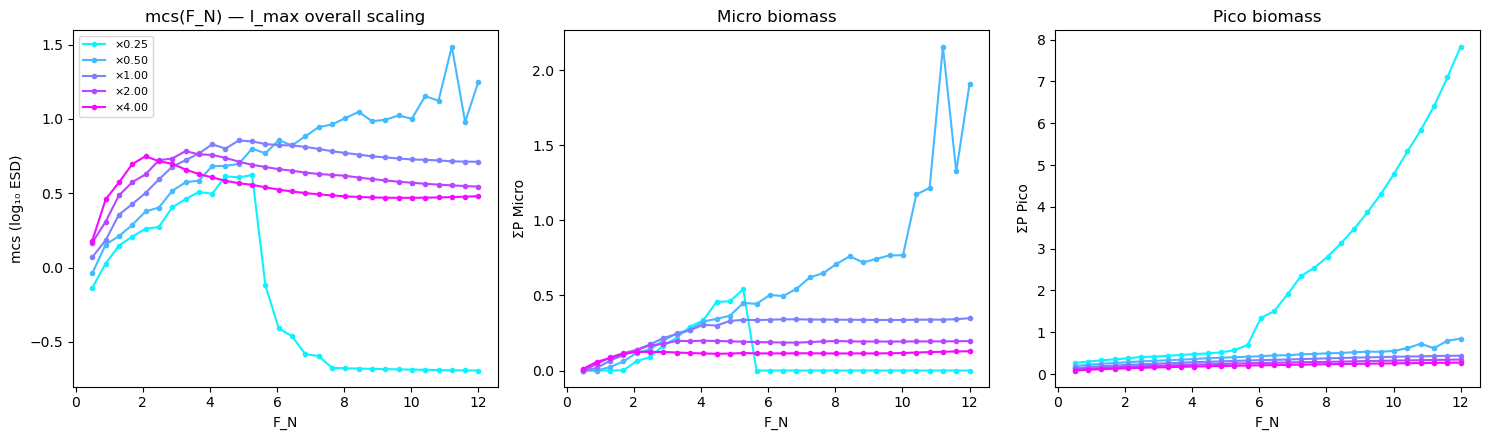

  I_max×0.25:  peak F_N =  5.26   mcs range = [-0.69, 0.62]
  I_max×0.50:  peak F_N = 11.21   mcs range = [-0.04, 1.49]
  I_max×1.00:  peak F_N =  4.86   mcs range = [0.07, 0.86]
  I_max×2.00:  peak F_N =  3.28   mcs range = [0.17, 0.78]
  I_max×4.00:  peak F_N =  2.09   mcs range = [0.18, 0.75]


In [23]:
# ---- Cell 19 — I_max overall scaling -------------------------------------
# Multiply the entire I_max array by a scalar — separates "magnitude" from
# "shape" of the grazing rate allometry. If the descending limb amplitude
# scales with overall grazing intensity, that's a magnitude signal; if it
# doesn't, the shape (plateau + allometry) is doing the work.
imax_scales = [0.25, 0.5, 1.0, 2.0, 4.0]                # ×1 = baseline
results_imax = []
for sc in imax_scales:
    res = run_layer(f'I_max × {sc:.2f}',
                    {'Grazing__Imax': ns.Imax_arr * sc})
    results_imax.append((sc, res))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
colors_i = plt.cm.cool(np.linspace(0.05, 0.95, len(imax_scales)))
for (sc, res), col in zip(results_imax, colors_i):
    axes[0].plot(res['FN'], res['mcs'],     '-o', color=col, label=f'×{sc:.2f}', ms=3)
    axes[1].plot(res['FN'], res['P_micro'], '-o', color=col, ms=3)
    axes[2].plot(res['FN'], res['P_pico'],  '-o', color=col, ms=3)
axes[0].set_xlabel('F_N'); axes[0].set_ylabel('mcs (log₁₀ ESD)')
axes[0].set_title('mcs(F_N) — I_max overall scaling'); axes[0].legend(fontsize=8)
axes[1].set_xlabel('F_N'); axes[1].set_ylabel('ΣP Micro'); axes[1].set_title('Micro biomass')
axes[2].set_xlabel('F_N'); axes[2].set_ylabel('ΣP Pico'); axes[2].set_title('Pico biomass')
plt.tight_layout(); plt.show()
for sc, res in results_imax:
    pk = int(np.argmax(res['mcs']))
    print(f"  I_max×{sc:.2f}:  peak F_N = {res['FN'][pk]:5.2f}   "
          f"mcs range = [{res['mcs'].min():.2f}, {res['mcs'].max():.2f}]")

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 35.48043 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 35.66498 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
-----------------------

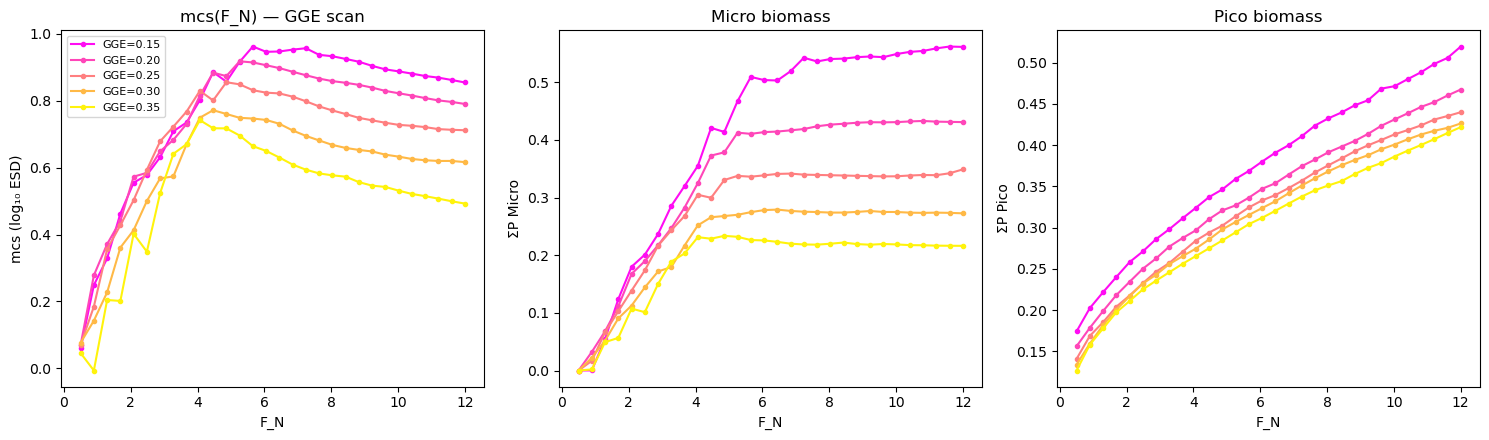

  GGE=0.15:  peak F_N =  5.66   mcs range = [0.06, 0.96]
  GGE=0.20:  peak F_N =  5.26   mcs range = [0.07, 0.92]
  GGE=0.25:  peak F_N =  4.86   mcs range = [0.07, 0.86]
  GGE=0.30:  peak F_N =  4.47   mcs range = [0.08, 0.77]
  GGE=0.35:  peak F_N =  4.07   mcs range = [-0.01, 0.74]


In [24]:
# ---- Cell 20 — GGE (gross growth efficiency) scan ------------------------
# Scalar in [0, 1]; baseline = 0.25 (Stock). Lower GGE → less efficient
# transfer P → Z and Z → Z. Should weaken the omnivory loop's amplification
# of large-Z biomass and may dampen the descending limb.
gge_values = [0.15, 0.20, 0.25, 0.30, 0.35]
results_gge = []
for gge in gge_values:
    res = run_layer(f'GGE = {gge:.2f}', {'GrazingRouter__gge': gge})
    results_gge.append((gge, res))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
colors_g = plt.cm.spring(np.linspace(0.05, 0.95, len(gge_values)))
for (gge, res), col in zip(results_gge, colors_g):
    axes[0].plot(res['FN'], res['mcs'],     '-o', color=col, label=f'GGE={gge:.2f}', ms=3)
    axes[1].plot(res['FN'], res['P_micro'], '-o', color=col, ms=3)
    axes[2].plot(res['FN'], res['P_pico'],  '-o', color=col, ms=3)
axes[0].set_xlabel('F_N'); axes[0].set_ylabel('mcs (log₁₀ ESD)')
axes[0].set_title('mcs(F_N) — GGE scan'); axes[0].legend(fontsize=8)
axes[1].set_xlabel('F_N'); axes[1].set_ylabel('ΣP Micro'); axes[1].set_title('Micro biomass')
axes[2].set_xlabel('F_N'); axes[2].set_ylabel('ΣP Pico'); axes[2].set_title('Pico biomass')
plt.tight_layout(); plt.show()
for gge, res in results_gge:
    pk = int(np.argmax(res['mcs']))
    print(f"  GGE={gge:.2f}:  peak F_N = {res['FN'][pk]:5.2f}   "
          f"mcs range = [{res['mcs'].min():.2f}, {res['mcs'].max():.2f}]")

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 42.4342 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 40.15338 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
------------------------

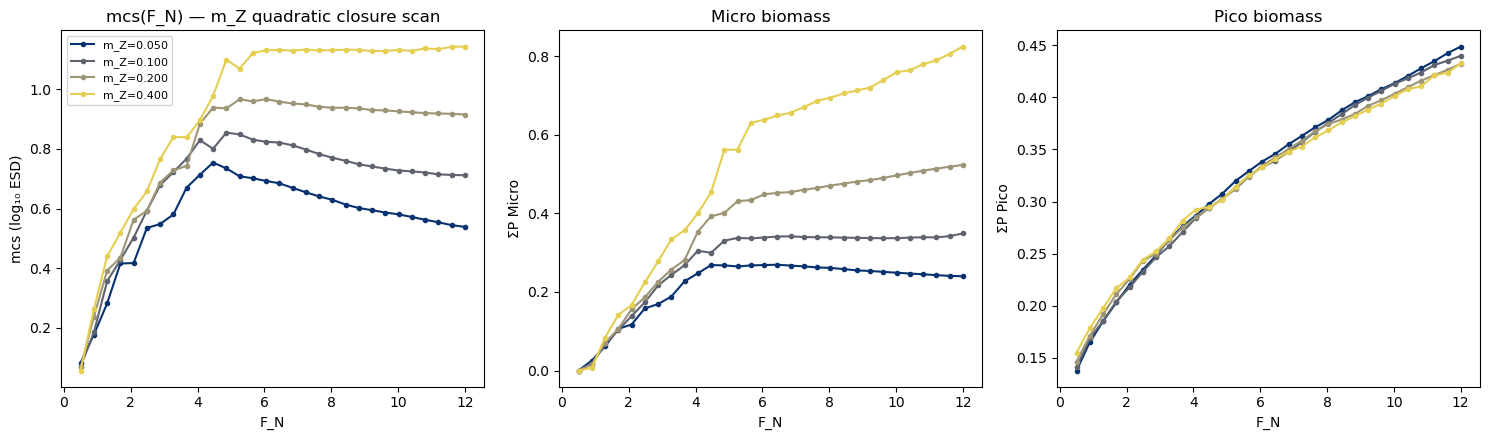

  m_Z=0.050:  peak F_N =  4.47   mcs range = [0.08, 0.75]   Micro(F_N=12)=0.240
  m_Z=0.100:  peak F_N =  4.86   mcs range = [0.07, 0.86]   Micro(F_N=12)=0.349
  m_Z=0.200:  peak F_N =  6.05   mcs range = [0.07, 0.97]   Micro(F_N=12)=0.523
  m_Z=0.400:  peak F_N = 12.00   mcs range = [0.06, 1.14]   Micro(F_N=12)=0.824


In [26]:
# ---- Cell 21 — m_Z quadratic zoo closure scan ----------------------------
# Baseline = 0.1. Banas 2011 Eq. 10 evaluated at MS3 allometries gives ≈ 0.26
# (memory project_banas synthesis); Banas's own base case ≈ 1.0. So baseline
# is on the low end; literature would support higher.
# Tests whether the regime transition seen with I_max × 0.5 is a *general*
# property of integrated top-down strength rather than I_max-specific.
m_Z_values = [0.05, 0.10, 0.20, 0.40]
results_mZ = []
for mZ in m_Z_values:
    res = run_layer(f'm_Z = {mZ:.3f}',
                    {'ZooQuadMortality__rate': mZ})
    results_mZ.append((mZ, res))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
colors_m = plt.cm.cividis(np.linspace(0.1, 0.9, len(m_Z_values)))
for (mZ, res), col in zip(results_mZ, colors_m):
    axes[0].plot(res['FN'], res['mcs'],     '-o', color=col, label=f'm_Z={mZ:.3f}', ms=3)
    axes[1].plot(res['FN'], res['P_micro'], '-o', color=col, ms=3)
    axes[2].plot(res['FN'], res['P_pico'],  '-o', color=col, ms=3)
axes[0].set_xlabel('F_N'); axes[0].set_ylabel('mcs (log₁₀ ESD)')
axes[0].set_title('mcs(F_N) — m_Z quadratic closure scan'); axes[0].legend(fontsize=8)
axes[1].set_xlabel('F_N'); axes[1].set_ylabel('ΣP Micro'); axes[1].set_title('Micro biomass')
axes[2].set_xlabel('F_N'); axes[2].set_ylabel('ΣP Pico'); axes[2].set_title('Pico biomass')
plt.tight_layout(); plt.show()
for mZ, res in results_mZ:
    pk = int(np.argmax(res['mcs']))
    print(f"  m_Z={mZ:.3f}:  peak F_N = {res['FN'][pk]:5.2f}   "
          f"mcs range = [{res['mcs'].min():.2f}, {res['mcs'].max():.2f}]   "
          f"Micro(F_N=12)={res['P_micro'][-1]:.3f}")

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 39.5299 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 37.62883 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
------------------------

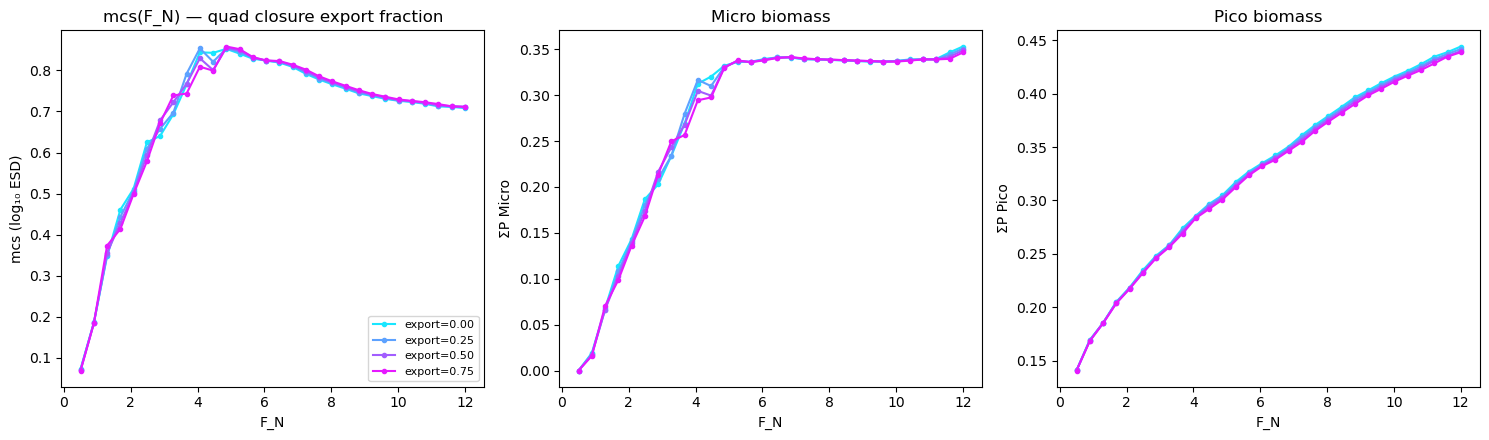

  export=0.00:  peak F_N =  4.86   mcs range = [0.07, 0.85]   Micro(F_N=12)=0.353
  export=0.25:  peak F_N =  4.07   mcs range = [0.07, 0.85]   Micro(F_N=12)=0.351
  export=0.50:  peak F_N =  4.86   mcs range = [0.07, 0.86]   Micro(F_N=12)=0.349
  export=0.75:  peak F_N =  4.86   mcs range = [0.07, 0.86]   Micro(F_N=12)=0.347


In [27]:
# ---- Cell 22 — Z quadratic closure export fraction scan ------------------
# Major N loss point in the model: baseline ZOO_QUAD_FRAC_EXPORT = 0.5
# (50% of quadratic closure exported out of the system; 50% to D).
# Scan: route 0/25/50/75% to export, rest to D (which gets remineralised
# via k_remin and partially lost via w_sink).
# Lower export → more N retained → more Micro accumulation expected.
export_fracs = [0.00, 0.25, 0.50, 0.75]
results_exp = []
for fe in export_fracs:
    res = run_layer(
        f'ZooQuad export = {fe:.2f}',
        {'ZooQuadMortality__frac_export': fe,
         'ZooQuadMortality__frac_D':       1.0 - fe},
    )
    results_exp.append((fe, res))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
colors_e = plt.cm.cool(np.linspace(0.1, 0.9, len(export_fracs)))
for (fe, res), col in zip(results_exp, colors_e):
    axes[0].plot(res['FN'], res['mcs'],     '-o', color=col, label=f'export={fe:.2f}', ms=3)
    axes[1].plot(res['FN'], res['P_micro'], '-o', color=col, ms=3)
    axes[2].plot(res['FN'], res['P_pico'],  '-o', color=col, ms=3)
axes[0].set_xlabel('F_N'); axes[0].set_ylabel('mcs (log₁₀ ESD)')
axes[0].set_title('mcs(F_N) — quad closure export fraction'); axes[0].legend(fontsize=8)
axes[1].set_xlabel('F_N'); axes[1].set_ylabel('ΣP Micro'); axes[1].set_title('Micro biomass')
axes[2].set_xlabel('F_N'); axes[2].set_ylabel('ΣP Pico'); axes[2].set_title('Pico biomass')
plt.tight_layout(); plt.show()
for fe, res in results_exp:
    pk = int(np.argmax(res['mcs']))
    print(f"  export={fe:.2f}:  peak F_N = {res['FN'][pk]:5.2f}   "
          f"mcs range = [{res['mcs'].min():.2f}, {res['mcs'].max():.2f}]   "
          f"Micro(F_N=12)={res['P_micro'][-1]:.3f}")

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 35.10926 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 35.63534 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
-----------------------

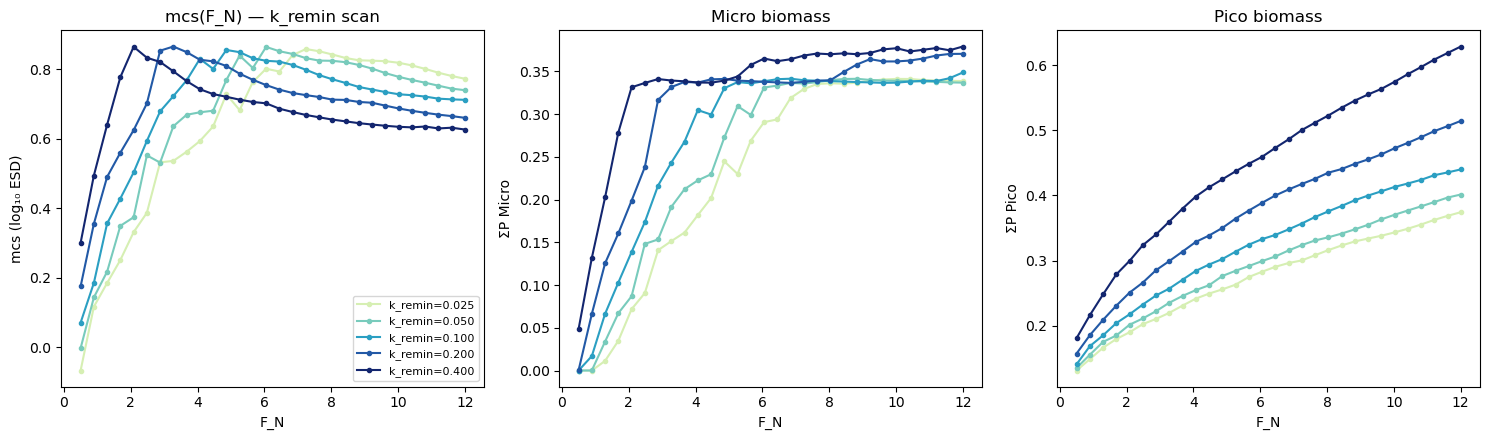

  k_remin=0.025:  peak F_N =  7.24   mcs range = [-0.07, 0.86]   Micro(F_N=12)=0.339
  k_remin=0.050:  peak F_N =  6.05   mcs range = [-0.00, 0.86]   Micro(F_N=12)=0.337
  k_remin=0.100:  peak F_N =  4.86   mcs range = [0.07, 0.86]   Micro(F_N=12)=0.349
  k_remin=0.200:  peak F_N =  3.28   mcs range = [0.17, 0.86]   Micro(F_N=12)=0.371
  k_remin=0.400:  peak F_N =  2.09   mcs range = [0.30, 0.86]   Micro(F_N=12)=0.379


In [28]:
# ---- Cell 23 — k_remin (detritus remineralisation rate) scan -------------
# Baseline = 0.1 d⁻¹ (warm-tropical default). Lower k_remin → D accumulates
# longer before becoming N; combined with w_sink (5 m/d) more D is lost to
# depth before remineralising. Higher k_remin → faster N regeneration.
k_remin_values = [0.025, 0.05, 0.10, 0.20, 0.40]
results_kr = []
for kr in k_remin_values:
    res = run_layer(f'k_remin = {kr:.3f}',
                    {'DetritusRemin__k_remin': kr})
    results_kr.append((kr, res))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
colors_r = plt.cm.YlGnBu(np.linspace(0.2, 0.95, len(k_remin_values)))
for (kr, res), col in zip(results_kr, colors_r):
    axes[0].plot(res['FN'], res['mcs'],     '-o', color=col, label=f'k_remin={kr:.3f}', ms=3)
    axes[1].plot(res['FN'], res['P_micro'], '-o', color=col, ms=3)
    axes[2].plot(res['FN'], res['P_pico'],  '-o', color=col, ms=3)
axes[0].set_xlabel('F_N'); axes[0].set_ylabel('mcs (log₁₀ ESD)')
axes[0].set_title('mcs(F_N) — k_remin scan'); axes[0].legend(fontsize=8)
axes[1].set_xlabel('F_N'); axes[1].set_ylabel('ΣP Micro'); axes[1].set_title('Micro biomass')
axes[2].set_xlabel('F_N'); axes[2].set_ylabel('ΣP Pico'); axes[2].set_title('Pico biomass')
plt.tight_layout(); plt.show()
for kr, res in results_kr:
    pk = int(np.argmax(res['mcs']))
    print(f"  k_remin={kr:.3f}:  peak F_N = {res['FN'][pk]:5.2f}   "
          f"mcs range = [{res['mcs'].min():.2f}, {res['mcs'].max():.2f}]   "
          f"Micro(F_N=12)={res['P_micro'][-1]:.3f}")

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=255.8 on Z[25] = -0.00144. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=1307 on P[6] = -0.00106. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=359.6 on P[10] = -0.404. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'

1D Scan complete. Time taken: 45.51343 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 54.03152 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 48.59873 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successfu

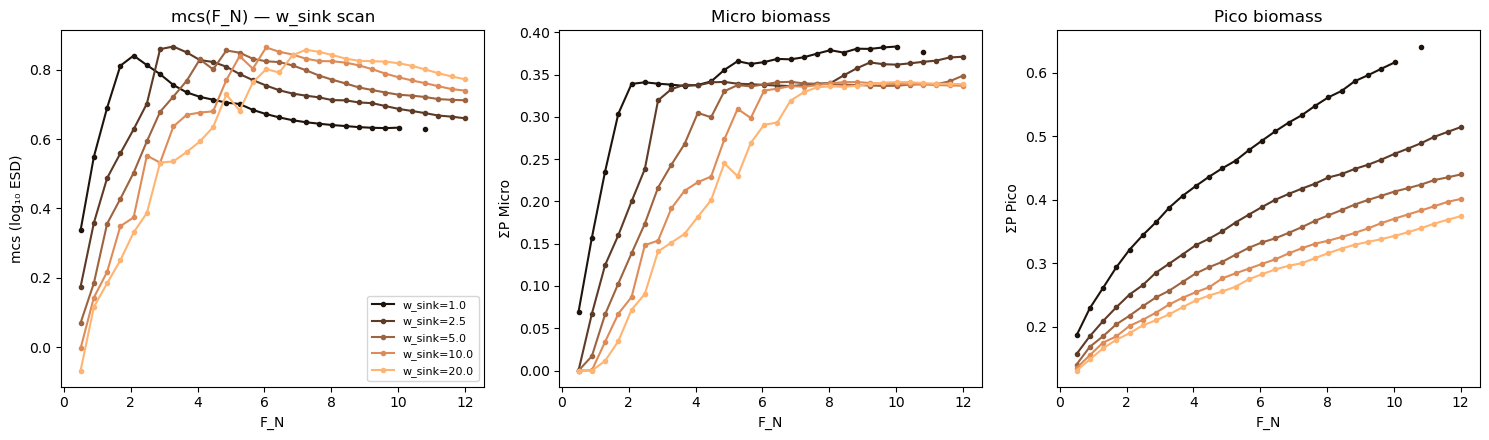

  w_sink=1.0:  peak F_N = 10.41   mcs range = [nan, nan]   Micro(F_N=12)=nan
  w_sink=2.5:  peak F_N =  3.28   mcs range = [0.17, 0.87]   Micro(F_N=12)=0.371
  w_sink=5.0:  peak F_N =  4.86   mcs range = [0.07, 0.86]   Micro(F_N=12)=0.349
  w_sink=10.0:  peak F_N =  6.05   mcs range = [-0.00, 0.86]   Micro(F_N=12)=0.337
  w_sink=20.0:  peak F_N =  7.24   mcs range = [-0.07, 0.86]   Micro(F_N=12)=0.339


In [29]:
# ---- Cell 24 — w_sink (detritus sinking velocity) scan -------------------
# Baseline = 5 m/d. Sinking rate (w_sink / d_e) sets the per-day fraction of
# D lost to depth before remineralising. Slower sinking → more D retained
# in box → more N regenerated locally → more bottom-up support for Micro.
w_sink_values = [1.0, 2.5, 5.0, 10.0, 20.0]
results_ws = []
for ws in w_sink_values:
    res = run_layer(f'w_sink = {ws:.1f} m/d',
                    {'DetritusSink__w_sink': ws})
    results_ws.append((ws, res))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
colors_w = plt.cm.copper(np.linspace(0.1, 0.9, len(w_sink_values)))
for (ws, res), col in zip(results_ws, colors_w):
    axes[0].plot(res['FN'], res['mcs'],     '-o', color=col, label=f'w_sink={ws:.1f}', ms=3)
    axes[1].plot(res['FN'], res['P_micro'], '-o', color=col, ms=3)
    axes[2].plot(res['FN'], res['P_pico'],  '-o', color=col, ms=3)
axes[0].set_xlabel('F_N'); axes[0].set_ylabel('mcs (log₁₀ ESD)')
axes[0].set_title('mcs(F_N) — w_sink scan'); axes[0].legend(fontsize=8)
axes[1].set_xlabel('F_N'); axes[1].set_ylabel('ΣP Micro'); axes[1].set_title('Micro biomass')
axes[2].set_xlabel('F_N'); axes[2].set_ylabel('ΣP Pico'); axes[2].set_title('Pico biomass')
plt.tight_layout(); plt.show()
for ws, res in results_ws:
    pk = int(np.argmax(res['mcs']))
    print(f"  w_sink={ws:.1f}:  peak F_N = {res['FN'][pk]:5.2f}   "
          f"mcs range = [{res['mcs'].min():.2f}, {res['mcs'].max():.2f}]   "
          f"Micro(F_N=12)={res['P_micro'][-1]:.3f}")

In [5]:
int(np.argmin(np.abs(ns.phyto_esd - 1.0)))

9

Pico class 0 ESD=0.20 µm,  Micro class 28 ESD=28.50 µm
Predator-of-Pico  Z class 0  ESD=2.00 µm
Predator-of-Micro Z class 28 ESD=285.02 µm


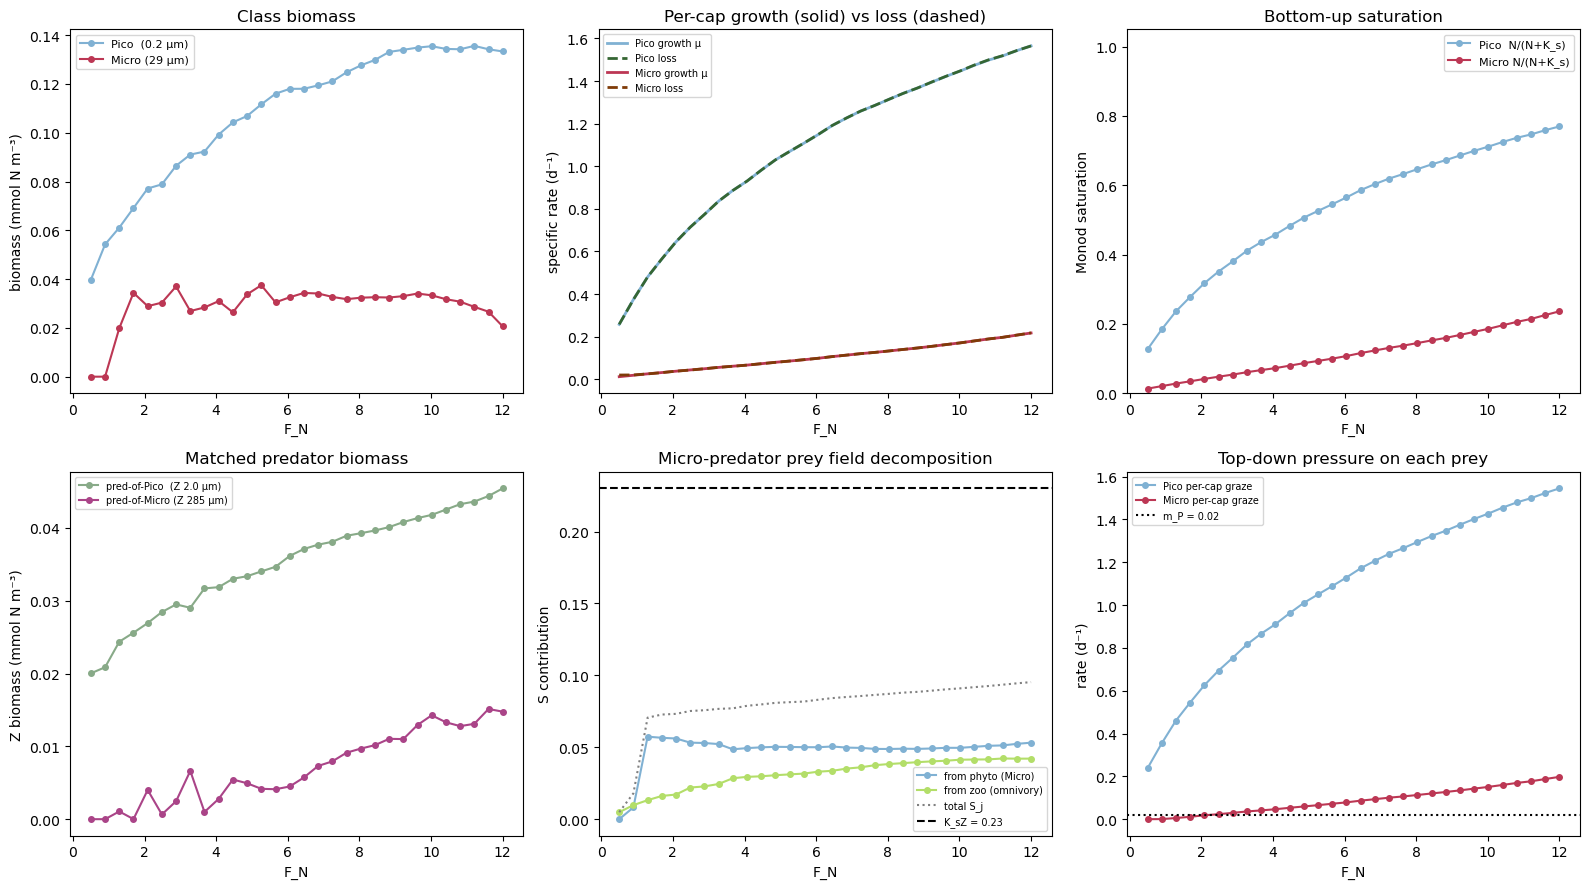

In [11]:
# ---- Cell 25 (fixed) — Pico vs Micro chain-tracing diagnostic ------------
# All constants pulled from ns directly so the cell is self-contained
# within the layered notebook.

# Replace the first two lines of Cell 25:
idx_pico  = 0                                                # smallest grid class
idx_micro = int(np.argmin(np.abs(ns.phyto_esd - 30.0)))      # ≈ 30 µm
print(f"Pico class {idx_pico} ESD={ns.phyto_esd[idx_pico]:.2f} µm,  "
      f"Micro class {idx_micro} ESD={ns.phyto_esd[idx_micro]:.2f} µm")

j_pred_pico  = int(np.argmax(ns.phiPZ_omni[idx_pico,  :]))
j_pred_micro = int(np.argmax(ns.phiPZ_omni[idx_micro, :]))
print(f"Predator-of-Pico  Z class {j_pred_pico}  ESD={ns.zoo_esd[j_pred_pico]:.2f} µm")
print(f"Predator-of-Micro Z class {j_pred_micro} ESD={ns.zoo_esd[j_pred_micro]:.2f} µm")

# Pull baseline scan
FN = layer2['FN']; P = layer2['P']; Z = layer2['Z']; N = layer2['N']
n_F = len(FN)

# Constants — pull from setups module
KsZ = float(ns.K_SZ)
phiPZ_full = ns.phiPZ_omni
Imax_arr   = ns.Imax_arr
m_P_base   = 0.02

# Per-cap growth (specific, intrinsic, T-corrected)
f_T_g = ns.Q10_GROW ** ((T_box - ns.T_REF) / 10.0)
mu_pico  = f_T_g * ns.mu_max_tani[idx_pico]  * N / (N + ns.ks_tani[idx_pico])
mu_micro = f_T_g * ns.mu_max_tani[idx_micro] * N / (N + ns.ks_tani[idx_micro])
sat_pico  = N / (N + ns.ks_tani[idx_pico])
sat_micro = N / (N + ns.ks_tani[idx_micro])

# Per-cap grazing pressure on each prey class (sum over predators)
f_T_z = ns.Q10_GRAZE ** ((T_box - ns.T_REF) / 10.0)
B = np.concatenate([P, Z], axis=1)
S_all = np.einsum('kj,fk->fj', phiPZ_full, B)
g_resp = S_all / (S_all**2 + KsZ**2)
per_cap_graze = f_T_z * np.einsum('j,fj,kj,fj->fk',
                                  Imax_arr, Z, phiPZ_full, g_resp)
loss_pico  = per_cap_graze[:, idx_pico]  + m_P_base
loss_micro = per_cap_graze[:, idx_micro] + m_P_base

# Omnivory decomposition for the Micro-predator's prey field
S_micro_pred_phyto = np.einsum('kj,fk->fj', phiPZ_full[:n_P, :], P)[:, j_pred_micro]
S_micro_pred_zoo   = np.einsum('kj,fk->fj', phiPZ_full[n_P:, :], Z)[:, j_pred_micro]

# 2x3 plot
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

ax = axes[0, 0]
ax.plot(FN, P[:, idx_pico],  '-o', color='#80b1d3',
        label=f'Pico  ({ns.phyto_esd[idx_pico]:.1f} µm)', ms=4)
ax.plot(FN, P[:, idx_micro], '-o', color='#bc3754',
        label=f'Micro ({ns.phyto_esd[idx_micro]:.0f} µm)', ms=4)
ax.set_xlabel('F_N'); ax.set_ylabel('biomass (mmol N m⁻³)')
ax.set_title('Class biomass'); ax.legend(fontsize=8)

ax = axes[0, 1]
ax.plot(FN, mu_pico,   '-',  color='#80b1d3', label='Pico growth μ', lw=2)
ax.plot(FN, loss_pico, '--', color='#356633', label='Pico loss',     lw=2)
ax.plot(FN, mu_micro,  '-',  color='#bc3754', label='Micro growth μ', lw=2)
ax.plot(FN, loss_micro,'--', color='#7f3b08', label='Micro loss',     lw=2)
ax.set_xlabel('F_N'); ax.set_ylabel('specific rate (d⁻¹)')
ax.set_title('Per-cap growth (solid) vs loss (dashed)'); ax.legend(fontsize=7)

ax = axes[0, 2]
ax.plot(FN, sat_pico,  '-o', color='#80b1d3', label='Pico  N/(N+K_s)',  ms=4)
ax.plot(FN, sat_micro, '-o', color='#bc3754', label='Micro N/(N+K_s)',  ms=4)
ax.set_xlabel('F_N'); ax.set_ylabel('Monod saturation')
ax.set_title('Bottom-up saturation'); ax.legend(fontsize=8); ax.set_ylim(0, 1.05)

ax = axes[1, 0]
ax.plot(FN, Z[:, j_pred_pico],  '-o', color='#88aa88',
        label=f'pred-of-Pico  (Z {ns.zoo_esd[j_pred_pico]:.1f} µm)', ms=4)
ax.plot(FN, Z[:, j_pred_micro], '-o', color='#aa4488',
        label=f'pred-of-Micro (Z {ns.zoo_esd[j_pred_micro]:.0f} µm)', ms=4)
ax.set_xlabel('F_N'); ax.set_ylabel('Z biomass (mmol N m⁻³)')
ax.set_title('Matched predator biomass'); ax.legend(fontsize=7)

ax = axes[1, 1]
ax.plot(FN, S_micro_pred_phyto, '-o', color='#80b1d3', label='from phyto (Micro)', ms=4)
ax.plot(FN, S_micro_pred_zoo,   '-o', color='#b3de69', label='from zoo (omnivory)', ms=4)
ax.plot(FN, S_micro_pred_phyto + S_micro_pred_zoo, ':', color='gray', label='total S_j')
ax.axhline(KsZ, color='k', ls='--', label=f'K_sZ = {KsZ}')
ax.set_xlabel('F_N'); ax.set_ylabel('S contribution')
ax.set_title('Micro-predator prey field decomposition'); ax.legend(fontsize=7)

ax = axes[1, 2]
ax.plot(FN, per_cap_graze[:, idx_pico],  '-o', color='#80b1d3', label='Pico per-cap graze',  ms=4)
ax.plot(FN, per_cap_graze[:, idx_micro], '-o', color='#bc3754', label='Micro per-cap graze', ms=4)
ax.axhline(m_P_base, color='k', ls=':', label=f'm_P = {m_P_base}')
ax.set_xlabel('F_N'); ax.set_ylabel('rate (d⁻¹)')
ax.set_title('Top-down pressure on each prey'); ax.legend(fontsize=7)

plt.tight_layout(); plt.show()

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd_perclassZ' and setup 'model_setup_npzd_tani_perclassZ_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 43.19819 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd_perclassZ' and setup 'model_setup_npzd_tani_perclassZ_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 36.49503 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd_perclassZ' and setup 'model_setup_npzd_tani_perclassZ_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validati

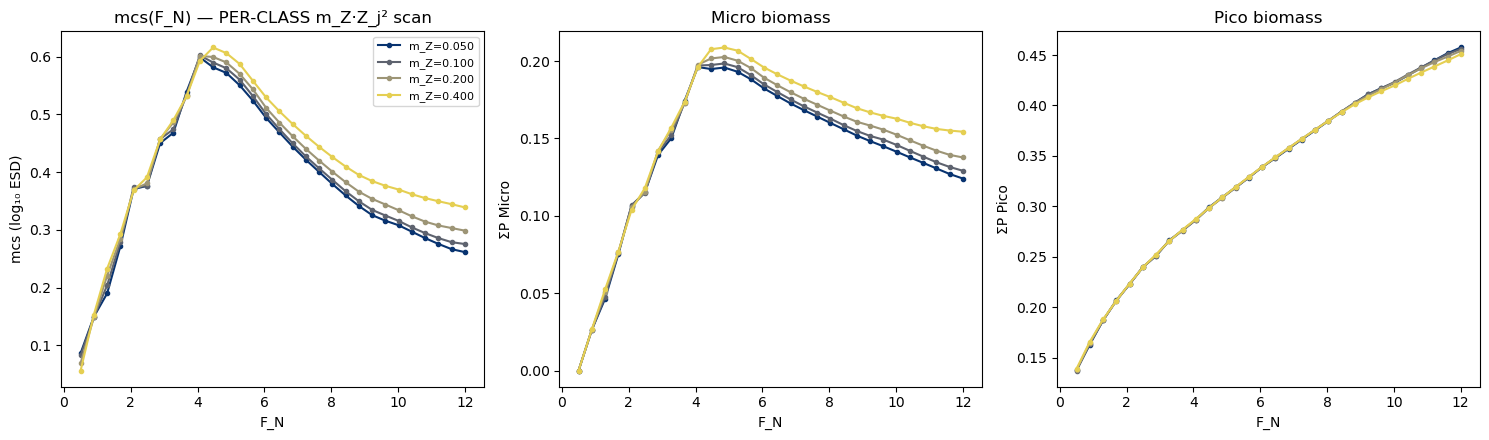

  m_Z=0.050:  peak F_N =  4.07   mcs range = [0.09, 0.60]   Micro(F_N=12)=0.124
  m_Z=0.100:  peak F_N =  4.07   mcs range = [0.08, 0.60]   Micro(F_N=12)=0.129
  m_Z=0.200:  peak F_N =  4.07   mcs range = [0.07, 0.60]   Micro(F_N=12)=0.138
  m_Z=0.400:  peak F_N =  4.47   mcs range = [0.06, 0.62]   Micro(F_N=12)=0.154


In [4]:
# ---- Cell 26 — per-class quadratic zoo closure scan ----------------------
# Uses model_npzd_perclassZ (new variant) — replaces bulk m_Z·Z_j·ΣZ with
# per-class m_Z·Z_j². Each Z class self-regulates without inter-class
# coupling through ΣZ. Same m_Z values as Cell 21 (bulk) so the two scans
# can be read side-by-side.
importlib.reload(ns)                                              # pick up new setups

m_Z_values_pc = [0.05, 0.10, 0.20, 0.40]
results_mZ_pc = []
for mZ in m_Z_values_pc:
    overrides = {**BASE_OVERRIDES, 'ZooQuadMortality__rate': mZ}
    scan = run_xso_parscan(
        model_file_name='cariaco_npzd_setups',
        model_name='model_npzd_perclassZ',
        model_setup_name='model_setup_npzd_tani_perclassZ_scan',
        param_name='Inflow__FN',
        param_values=FN_VALUES,
        fixed_overrides=overrides,
        postprocess_name='avg_tail',
        postprocess_kwargs={'avg_window': 1000},
        processes=8,
    )
    o   = np.argsort(scan['Inflow__FN'].values)
    FN_ = scan['Inflow__FN'].values[o]
    P_  = scan['Phytoplankton__biomass'].squeeze('time').values[o]
    Z_  = scan['Zooplankton__biomass'].squeeze('time').values[o]
    N_  = scan['Nutrient__value'].squeeze('time').values[o]
    mcs_= (P_ * np.log10(ns.phyto_esd)[None, :]).sum(axis=1) / np.maximum(P_.sum(axis=1), 1e-30)
    results_mZ_pc.append(dict(
        mZ=mZ, FN=FN_, P=P_, Z=Z_, N=N_, mcs=mcs_,
        P_pico=P_[:, m_pico].sum(axis=1),
        P_nano=P_[:, m_nano].sum(axis=1),
        P_micro=P_[:, m_micro].sum(axis=1),
    ))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
colors_pc = plt.cm.cividis(np.linspace(0.1, 0.9, len(m_Z_values_pc)))
for res, col in zip(results_mZ_pc, colors_pc):
    axes[0].plot(res['FN'], res['mcs'],     '-o', color=col, label=f'm_Z={res["mZ"]:.3f}', ms=3)
    axes[1].plot(res['FN'], res['P_micro'], '-o', color=col, ms=3)
    axes[2].plot(res['FN'], res['P_pico'],  '-o', color=col, ms=3)
axes[0].set_xlabel('F_N'); axes[0].set_ylabel('mcs (log₁₀ ESD)')
axes[0].set_title('mcs(F_N) — PER-CLASS m_Z·Z_j² scan'); axes[0].legend(fontsize=8)
axes[1].set_xlabel('F_N'); axes[1].set_ylabel('ΣP Micro'); axes[1].set_title('Micro biomass')
axes[2].set_xlabel('F_N'); axes[2].set_ylabel('ΣP Pico'); axes[2].set_title('Pico biomass')
plt.tight_layout(); plt.show()
for res in results_mZ_pc:
    pk = int(np.argmax(res['mcs']))
    print(f"  m_Z={res['mZ']:.3f}:  peak F_N = {res['FN'][pk]:5.2f}   "
          f"mcs range = [{res['mcs'].min():.2f}, {res['mcs'].max():.2f}]   "
          f"Micro(F_N=12)={res['P_micro'][-1]:.3f}")

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan_long' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 154.14736 seconds.


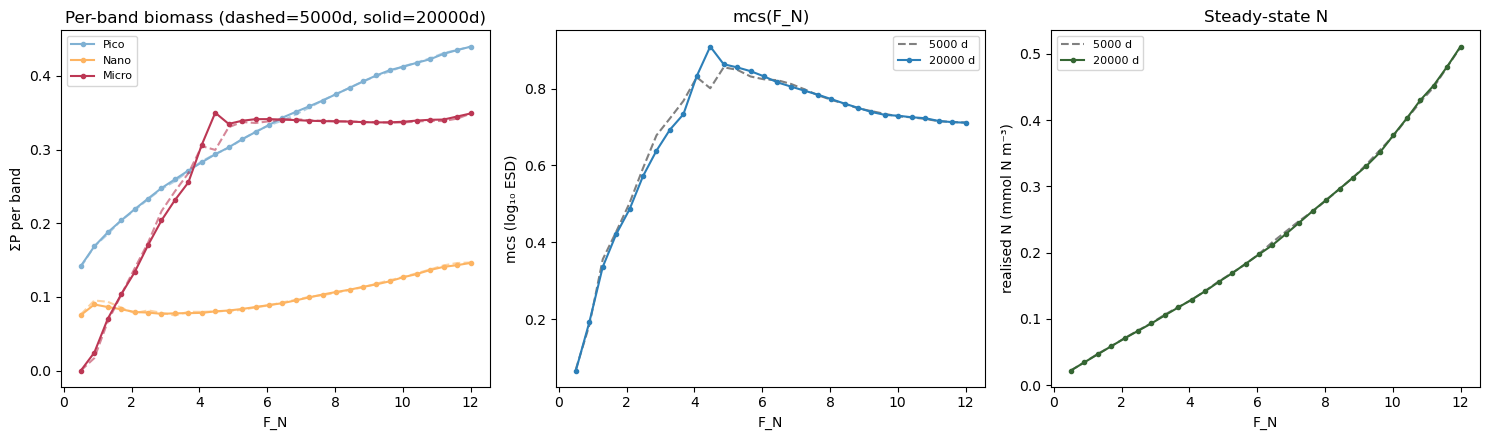

5000 d   peak F_N = 4.86   mcs range = [0.07, 0.86]
20000 d  peak F_N = 4.47   mcs range = [0.07, 0.91]


In [14]:
# ---- Cell 27 — Longer integration time (5000 d → 20000 d) ----------------
# Re-run the baseline (L2-equivalent) using model_setup_npzd_tani_scan_long
# (4× longer integration), compare per-band biomass + mcs to the standard scan.
# Tests whether the descending limb / Micro plateau are stable equilibria or
# slow transients still settling.
importlib.reload(ns)

overrides_long = {k: v for k, v in BASE_OVERRIDES.items()}
scan_long = run_xso_parscan(
    model_file_name='cariaco_npzd_setups',
    model_name='model_npzd',
    model_setup_name='model_setup_npzd_tani_scan_long',
    param_name='Inflow__FN',
    param_values=FN_VALUES,
    fixed_overrides=overrides_long,
    postprocess_name='avg_tail',
    postprocess_kwargs={'avg_window': 4000},     # match the longer tail
    processes=8,
)
o   = np.argsort(scan_long['Inflow__FN'].values)
FN_ = scan_long['Inflow__FN'].values[o]
P_  = scan_long['Phytoplankton__biomass'].squeeze('time').values[o]
N_  = scan_long['Nutrient__value'].squeeze('time').values[o]
mcs_= (P_ * np.log10(ns.phyto_esd)[None, :]).sum(axis=1) / np.maximum(P_.sum(axis=1), 1e-30)
layer_long = dict(
    label='L2 long (20000 d)', FN=FN_, P=P_, N=N_, mcs=mcs_,
    peak_idx=int(np.argmax(mcs_)), peak_FN=FN_[int(np.argmax(mcs_))],
    P_pico=P_[:, m_pico].sum(axis=1),
    P_nano=P_[:, m_nano].sum(axis=1),
    P_micro=P_[:, m_micro].sum(axis=1),
)

# Side-by-side comparison: standard (layer2) dashed vs long solid
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
bands = [('Pico', 'P_pico', '#80b1d3'),
         ('Nano', 'P_nano', '#fdb462'),
         ('Micro', 'P_micro', '#bc3754')]
for lbl, key, col in bands:
    axes[0].plot(layer2['FN'], layer2[key], '--', color=col, alpha=0.6)
    axes[0].plot(layer_long['FN'], layer_long[key], '-o', color=col, label=lbl, ms=3)
axes[0].set_xlabel('F_N'); axes[0].set_ylabel('ΣP per band')
axes[0].set_title('Per-band biomass (dashed=5000d, solid=20000d)'); axes[0].legend(fontsize=8)

axes[1].plot(layer2['FN'], layer2['mcs'], '--', color='gray', label='5000 d')
axes[1].plot(layer_long['FN'], layer_long['mcs'], '-o', color='#2c7fb8', label='20000 d', ms=3)
axes[1].set_xlabel('F_N'); axes[1].set_ylabel('mcs (log₁₀ ESD)')
axes[1].set_title('mcs(F_N)'); axes[1].legend(fontsize=8)

axes[2].plot(layer2['FN'], layer2['N'], '--', color='gray', label='5000 d')
axes[2].plot(layer_long['FN'], layer_long['N'], '-o', color='#356633', label='20000 d', ms=3)
axes[2].set_xlabel('F_N'); axes[2].set_ylabel('realised N (mmol N m⁻³)')
axes[2].set_title('Steady-state N'); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"5000 d   peak F_N = {layer2['peak_FN']:.2f}   "
      f"mcs range = [{layer2['mcs'].min():.2f}, {layer2['mcs'].max():.2f}]")
print(f"20000 d  peak F_N = {layer_long['peak_FN']:.2f}   "
      f"mcs range = [{layer_long['mcs'].min():.2f}, {layer_long['mcs'].max():.2f}]")

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan_lores' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 23.51995 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 30 points using 8 workers...
1D Scan complete. Time taken: 41.64144 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan_hires' from 'cariaco_npzd_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
-----------

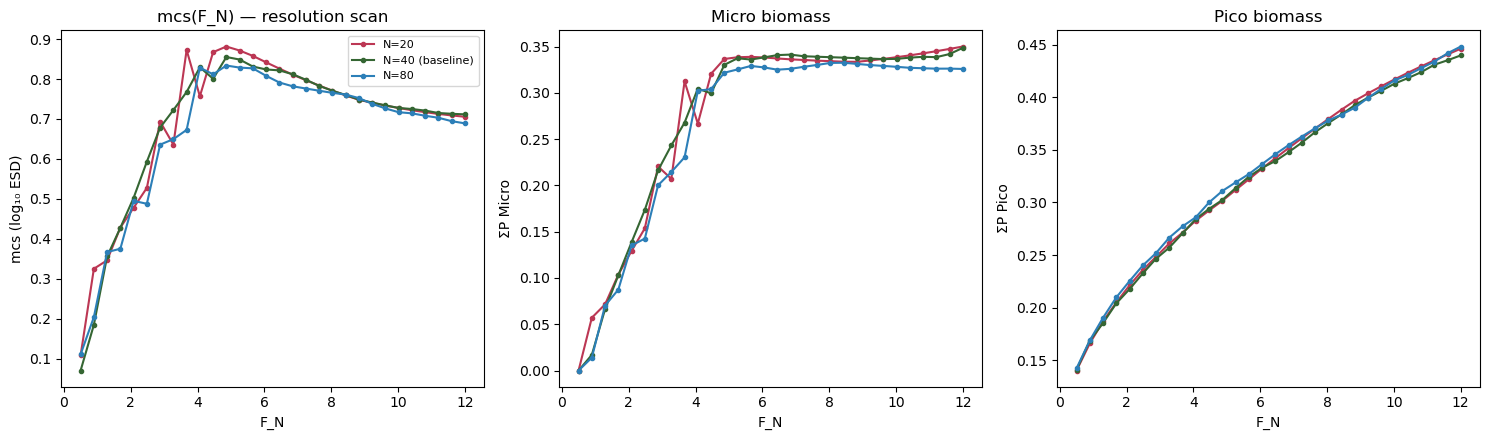

                N=20:  peak F_N =  4.86   mcs range = [0.11, 0.88]
     N=40 (baseline):  peak F_N =  4.86   mcs range = [0.07, 0.86]
                N=80:  peak F_N =  4.86   mcs range = [0.11, 0.83]


In [15]:
# ---- Cell 28 — Resolution sensitivity (N_CLASSES ∈ {20, 40, 80}) --------
# Tests whether the descending limb / mcs(F_N) shape depends on grid density.
# Banas 2011 (Fig. 12b) reports abrupt regime change below ~6 classes,
# stable behaviour above. We test below baseline (20) and above (80).
importlib.reload(ns)

resolutions = [
    ('N=20', 'model_setup_npzd_tani_scan_lores', ns.phyto_esd_lores, '#bc3754'),
    ('N=40 (baseline)', 'model_setup_npzd_tani_scan',   ns.phyto_esd, '#356633'),
    ('N=80', 'model_setup_npzd_tani_scan_hires', ns.phyto_esd_hires, '#2c7fb8'),
]
results_res = []
for lbl, setup_name, phyto_esd_v, col in resolutions:
    n_P_v = phyto_esd_v.size
    # PhytoMortality__rate is array-dim'd per-class; default is mP_tani for that
    # resolution (already in the setup). For uniform 0.02 comparison we override:
    overrides_r = {k: v for k, v in BASE_OVERRIDES.items() if k != 'PhytoMortality__rate'}
    overrides_r['PhytoMortality__rate'] = np.full(n_P_v, 0.02)
    scan_r = run_xso_parscan(
        model_file_name='cariaco_npzd_setups',
        model_name='model_npzd',
        model_setup_name=setup_name,
        param_name='Inflow__FN',
        param_values=FN_VALUES,
        fixed_overrides=overrides_r,
        postprocess_name='avg_tail',
        postprocess_kwargs={'avg_window': 1000},
        processes=8,
    )
    o = np.argsort(scan_r['Inflow__FN'].values)
    FN_r = scan_r['Inflow__FN'].values[o]
    P_r  = scan_r['Phytoplankton__biomass'].squeeze('time').values[o]
    log_esd = np.log10(phyto_esd_v)
    mcs_r = (P_r * log_esd[None, :]).sum(axis=1) / np.maximum(P_r.sum(axis=1), 1e-30)
    mp_pico  = phyto_esd_v < 2.0
    mp_nano  = (phyto_esd_v >= 2.0) & (phyto_esd_v < 20.0)
    mp_micro = phyto_esd_v >= 20.0
    results_res.append(dict(
        label=lbl, FN=FN_r, mcs=mcs_r, color=col,
        P_pico=P_r[:, mp_pico ].sum(axis=1),
        P_nano=P_r[:, mp_nano ].sum(axis=1),
        P_micro=P_r[:, mp_micro].sum(axis=1),
    ))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for res in results_res:
    axes[0].plot(res['FN'], res['mcs'],     '-o', color=res['color'], label=res['label'], ms=3)
    axes[1].plot(res['FN'], res['P_micro'], '-o', color=res['color'], ms=3)
    axes[2].plot(res['FN'], res['P_pico'],  '-o', color=res['color'], ms=3)
axes[0].set_xlabel('F_N'); axes[0].set_ylabel('mcs (log₁₀ ESD)')
axes[0].set_title('mcs(F_N) — resolution scan'); axes[0].legend(fontsize=8)
axes[1].set_xlabel('F_N'); axes[1].set_ylabel('ΣP Micro'); axes[1].set_title('Micro biomass')
axes[2].set_xlabel('F_N'); axes[2].set_ylabel('ΣP Pico'); axes[2].set_title('Pico biomass')
plt.tight_layout(); plt.show()

for res in results_res:
    pk = int(np.argmax(res['mcs']))
    print(f"  {res['label']:>18}:  peak F_N = {res['FN'][pk]:5.2f}   "
          f"mcs range = [{res['mcs'].min():.2f}, {res['mcs'].max():.2f}]")